# Лабораторная работа №2 — Временные ряды
## Многомерный прогноз температуры по нескольким городам

In [2]:
import pandas as pd
import openpyxl

file_path = 'have_fun.xlsx'

wb = openpyxl.load_workbook(file_path)

print("=== Анализ структуры Excel-файла ===")
print(f"Все найденные листы: {wb.sheetnames}\n")

for sheet in wb.worksheets:
    state = sheet.sheet_state
    if state != 'visible':
        print(f"ВНИМАНИЕ: Обнаружен скрытый лист -> '{sheet.title}' (статус: {state})")
    else:
        print(f"Видимый лист -> '{sheet.title}'")

print("\n=== Чтение данных в Pandas ===")
dfs = pd.read_excel(file_path, sheet_name=None)

for sheet_name, df in dfs.items():
    print(f"\nЛист: '{sheet_name}'  |  Размерность: {df.shape}")
    display(df.head(3))


=== Анализ структуры Excel-файла ===
Все найденные листы: ['Ëèñò1', 'Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']

Видимый лист -> 'Ëèñò1'
Видимый лист -> 'Лист1'
Видимый лист -> 'ÌÀÈ'
Видимый лист -> 'ýòî'
Видимый лист -> 'ÿ'
Видимый лист -> '!'
ВНИМАНИЕ: Обнаружен скрытый лист -> 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû' (статус: hidden)
ВНИМАНИЕ: Обнаружен скрытый лист -> 'Ëèñò3_ñìåøàííûå_òèïû' (статус: hidden)

=== Чтение данных в Pandas ===

Лист: 'Ëèñò1'  |  Размерность: (125124, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.8,82,0.0,0.0,0.0,3,19.1,1010.000000,2020-01-31 02:00:00,Ãåëåíäæèê
1,-3.0,70,0.0,0.0,0.0,3,24.0,981.900024,2025-02-28 09:00:00,Áëàãîâåùåíñê
2,-1.3,86,0.0,0.0,0.0,2,8.8,1021.200012,2022-01-03 02:00:00,Ãåëåíäæèê



Лист: 'Лист1'  |  Размерность: (0, 0)


""



Лист: 'ÌÀÈ'  |  Размерность: (0, 0)


...

""



Лист: 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû'  |  Размерность: (125169, 25)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,-6.5,92.0,0,0.0,0.0,3.0,10.8,1000.500000,2019-01-01 00:00:00,Ìîñêâà,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-6.8,92.0,0,0.0,0.0,3.0,10.5,1000.299988,2019-01-01 01:00:00,Ìîñêâà,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-6.8,92.0,0,0.0,0.0,3.0,10.8,1000.000000,2019-01-01 02:00:00,Ìîñêâà,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Лист: 'Ëèñò3_ñìåøàííûå_òèïû'  |  Размерность: (122736, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-1.8,85.0,0,0.0,0.0,3,23.5,1015.200012,2019-01-01 00:00:00,Ñàíêò-Ïåòåðáóðã
1,-1.9,83.0,0,0.0,0.0,3,26,1013.200012,2019-01-01 01:00:00,Ñàíêò-Ïåòåðáóðã
2,-2,85.0,0,0.0,0.0,3,26.200001,1011.700012,2019-01-01 02:00:00,Ñàíêò-Ïåòåðáóðã


In [3]:
# Оставляем ровно 3 листа с данными (один из них виден только через openpyxl)
target_sheets = ['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']
df_list = []

for sheet in target_sheets:
    df = dfs[sheet].copy()
    # Удаляем пустые Unnamed-колонки (артефакт второго листа)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df_list.append(df)

full_df = pd.concat(df_list, ignore_index=True)

def fix_encoding(text):
    """Восстанавливаем cp1251-текст, сохранённый как latin-1 (типичная проблема Excel)."""
    if isinstance(text, str):
        try:
            return text.encode('latin-1').decode('cp1251')
        except Exception:
            return text
    return text

full_df['city'] = full_df['city'].apply(fix_encoding)
full_df['ds']   = pd.to_datetime(full_df['ds'], errors='coerce')

print("=== Результаты объединения ===")
print(f"Размерность: {full_df.shape}")
print("\nУникальные города (сырые, до нормализации):")
print(full_df['city'].unique())
print("\nТипы данных:")
print(full_df.dtypes)
print("\nПропуски:")
print(full_df.isna().sum())


=== Результаты объединения ===
Размерность: (373029, 10)

Уникальные города (сырые, до нормализации):
['Геленджик' 'Благовещенск' 'БЛАГОВЕЩЕНСК' 'Благовещенс' 'Благовещенскк'
 'благовещенск' 'ГЕЛЕНДЖИК' 'геленджик' 'Геленджикк' 'Геленджи' 'Москва'
 nan 'Мосва' 'Находка' 'Санкт-Петербург' 'Сочи' 'Сычи' 'Счи' 'Соч']

Типы данных:
temperature_2m                  object
relative_humidity_2m           float64
precipitation                   object
rain                           float64
snowfall                       float64
weathercode                     object
wind_speed_10m                  object
surface_pressure               float64
ds                      datetime64[ns]
city                            object
dtype: object

Пропуски:
temperature_2m          5013
relative_humidity_2m    2459
precipitation           4637
rain                    2484
snowfall                2484
weathercode             2485
wind_speed_10m          4086
surface_pressure        2485
ds                     

In [4]:
import numpy as np

print("=== Глубокая очистка данных ===\n")

# ── 1. Нормализация названий городов ──────────────────────────────────────
city_map = {
    'ГЕЛЕНДЖИК':      'Геленджик',  'геленджик':       'Геленджик',
    'Геленджикк':     'Геленджик',  'Геленджи':         'Геленджик',
    'БЛАГОВЕЩЕНСК':   'Благовещенск', 'Благовещенс':   'Благовещенск',
    'Благовещенскк':  'Благовещенск', 'благовещенск':  'Благовещенск',
    'Мосва':          'Москва',
    'Сычи':           'Сочи',        'Счи':             'Сочи',
    'Соч':            'Сочи',
}
full_df['city'] = full_df['city'].replace(city_map)

# ── 2. Удаляем строки без даты или города ─────────────────────────────────
full_df.dropna(subset=['ds', 'city'], inplace=True)

# ── 3. Приводим строковые числа к float (запятая -> точка) ────────────────
numeric_raw = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
               'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']
for col in numeric_raw:
    if full_df[col].dtype == object:
        full_df[col] = (full_df[col].astype(str)
                                    .str.replace(',', '.', regex=False))
        full_df[col] = pd.to_numeric(full_df[col], errors='coerce')

# ── 4. Дедупликация ────────────────────────────────────────────────────────
full_df.drop_duplicates(inplace=True)
full_df.sort_values(['city', 'ds'], inplace=True)
full_df.drop_duplicates(subset=['city', 'ds'], keep='first', inplace=True)

# ── 5. Обработка выбросов — физические границы для температуры ────────────
print("--- Физические выбросы (температура вне [-80, 60]°C) ---")
temp_bad = (full_df['temperature_2m'] < -80) | (full_df['temperature_2m'] > 60)
print(f"Найдено: {temp_bad.sum()} записей  ->  заменяем на NaN")
full_df.loc[temp_bad, 'temperature_2m'] = np.nan

# ── 6. IQR-клиппинг по каждому городу (мультипликатор 3.0) ────────────────
print("\n--- IQR-клиппинг температуры по городам (множитель=3.0) ---")
def iqr_clip_series(s, k=3.0):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    clipped = s.clip(lo, hi)
    n_out = ((s < lo) | (s > hi)).sum()
    return clipped, n_out, lo, hi

for city in full_df['city'].unique():
    mask = full_df['city'] == city
    clipped, n, lo, hi = iqr_clip_series(full_df.loc[mask, 'temperature_2m'])
    full_df.loc[mask, 'temperature_2m'] = clipped
    if n > 0:
        print(f"  {city}: заменено {n} выбросов, допустимый диапазон [{lo:.1f}, {hi:.1f}]°C")

# ── 7. Устанавливаем ds как индекс, интерполируем пропуски ────────────────
full_df.set_index('ds', inplace=True)
num_cols = full_df.select_dtypes(include='number').columns
full_df[num_cols] = full_df.groupby('city')[num_cols].transform(
    lambda x: x.interpolate(method='time').bfill().ffill()
)

print("\n=== Итог очистки ===")
print(f"Размерность: {full_df.shape}")
print(f"Уникальные города: {sorted(full_df['city'].unique())}")
print("\nПропуски после интерполяции:")
print(full_df.isna().sum())
print("\nПериоды наблюдений:")
for city in sorted(full_df['city'].unique()):
    sub = full_df[full_df['city'] == city]
    print(f"  {city}: {sub.index.min().date()} — {sub.index.max().date()}  ({len(sub):,} ч/записей)")


=== Глубокая очистка данных ===

--- Физические выбросы (температура вне [-80, 60]°C) ---
Найдено: 427 записей  ->  заменяем на NaN

--- IQR-клиппинг температуры по городам (множитель=3.0) ---

=== Итог очистки ===
Размерность: (368090, 9)
Уникальные города: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']

Пропуски после интерполяции:
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
city                    0
dtype: int64

Периоды наблюдений:
  Благовещенск: 2019-01-01 — 2025-12-31  (61,336 ч/записей)
  Геленджик: 2019-01-01 — 2025-12-31  (61,337 ч/записей)
  Москва: 2019-01-01 — 2025-12-31  (61,364 ч/записей)
  Находка: 2019-01-01 — 2025-12-31  (61,317 ч/записей)
  Санкт-Петербург: 2019-01-01 — 2025-12-31  (61,368 ч/записей)
  Сочи: 2019-01-01 — 2025-12-31  (61,368 ч/записей)


Города в датасете: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']



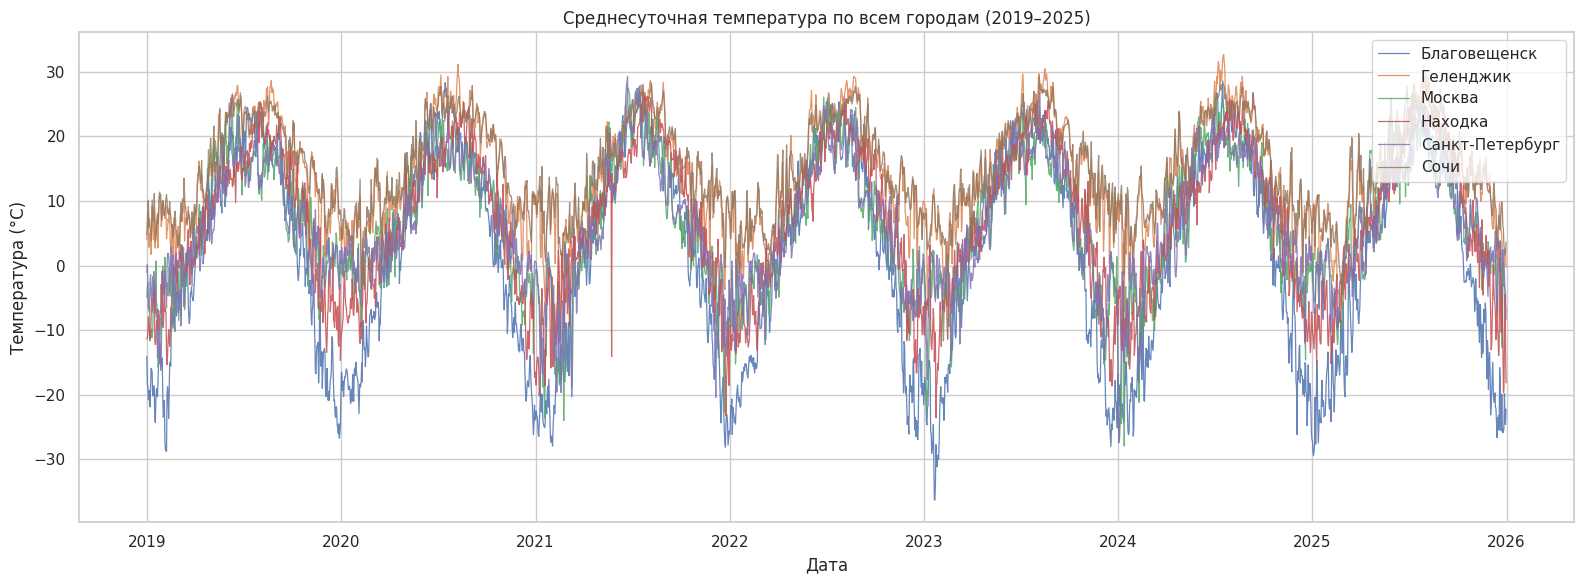

  Город: Благовещенск  |  записей: 2557
ADF = -3.3324  |  p-value = 1.3491e-02  =>  СТАЦИОНАРЕН ✅
  Крит. значение 1%: -3.4329
  Крит. значение 5%: -2.8627
  Крит. значение 10%: -2.5674


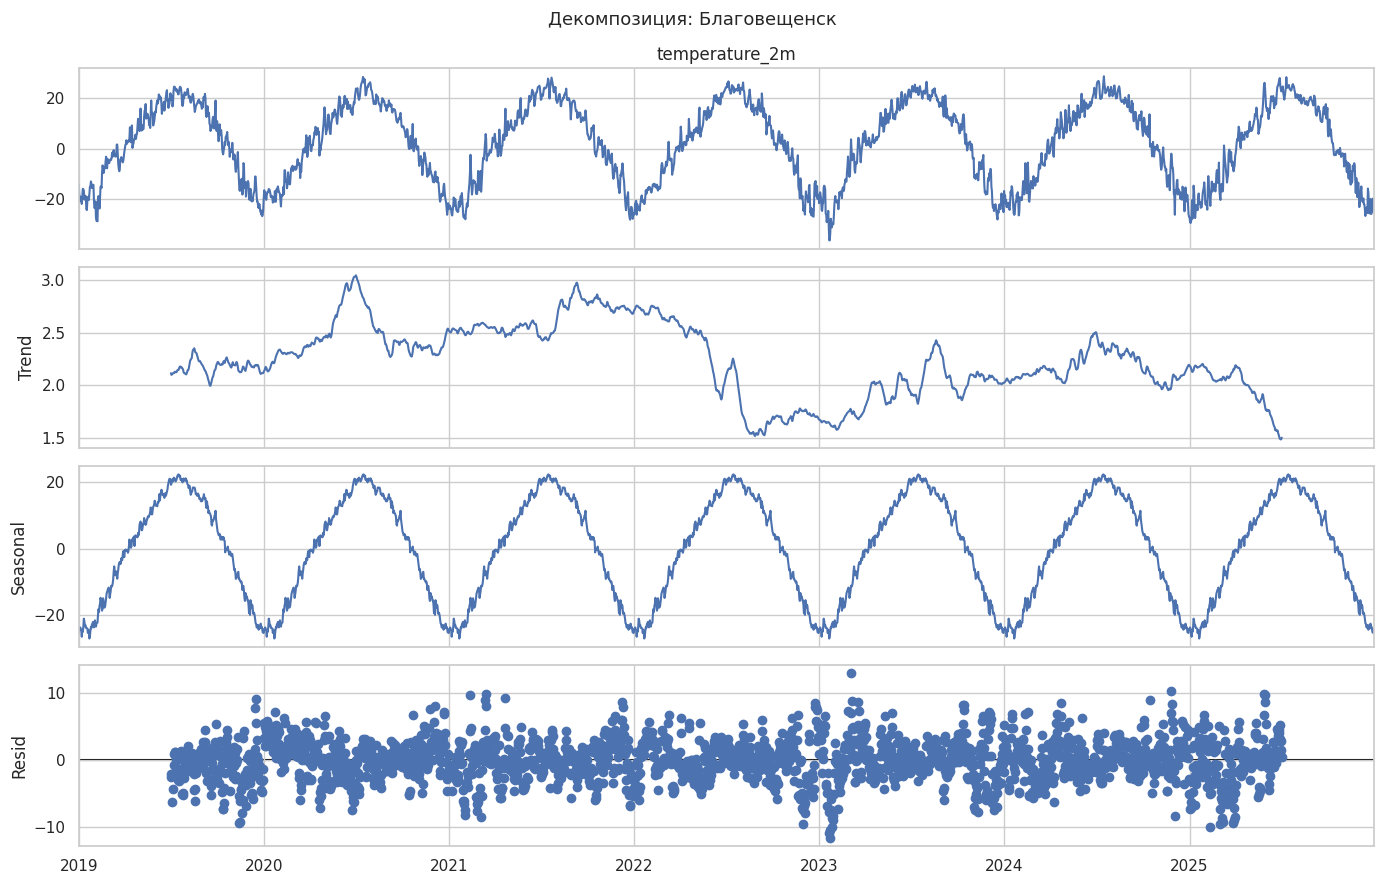

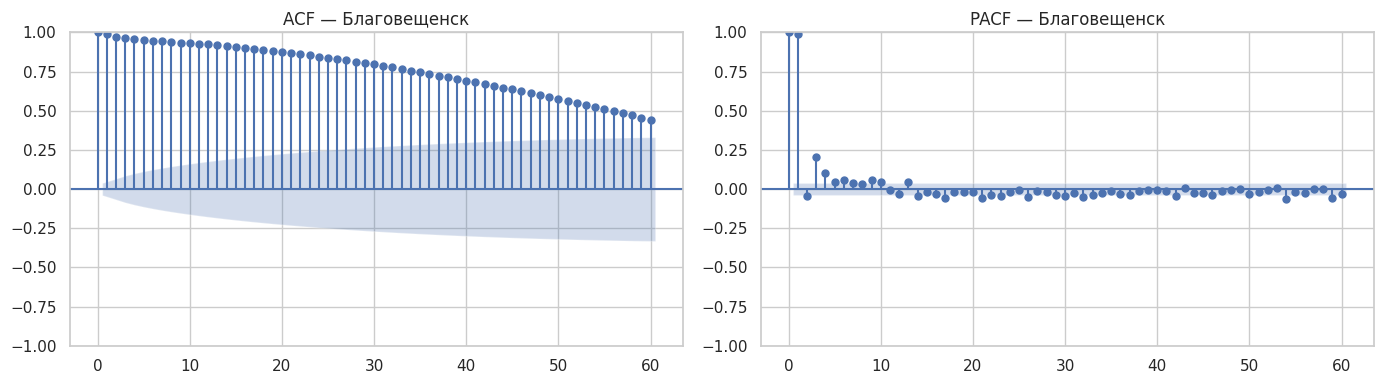


  Город: Геленджик  |  записей: 2557
ADF = -3.0111  |  p-value = 3.3867e-02  =>  СТАЦИОНАРЕН ✅
  Крит. значение 1%: -3.4329
  Крит. значение 5%: -2.8627
  Крит. значение 10%: -2.5674


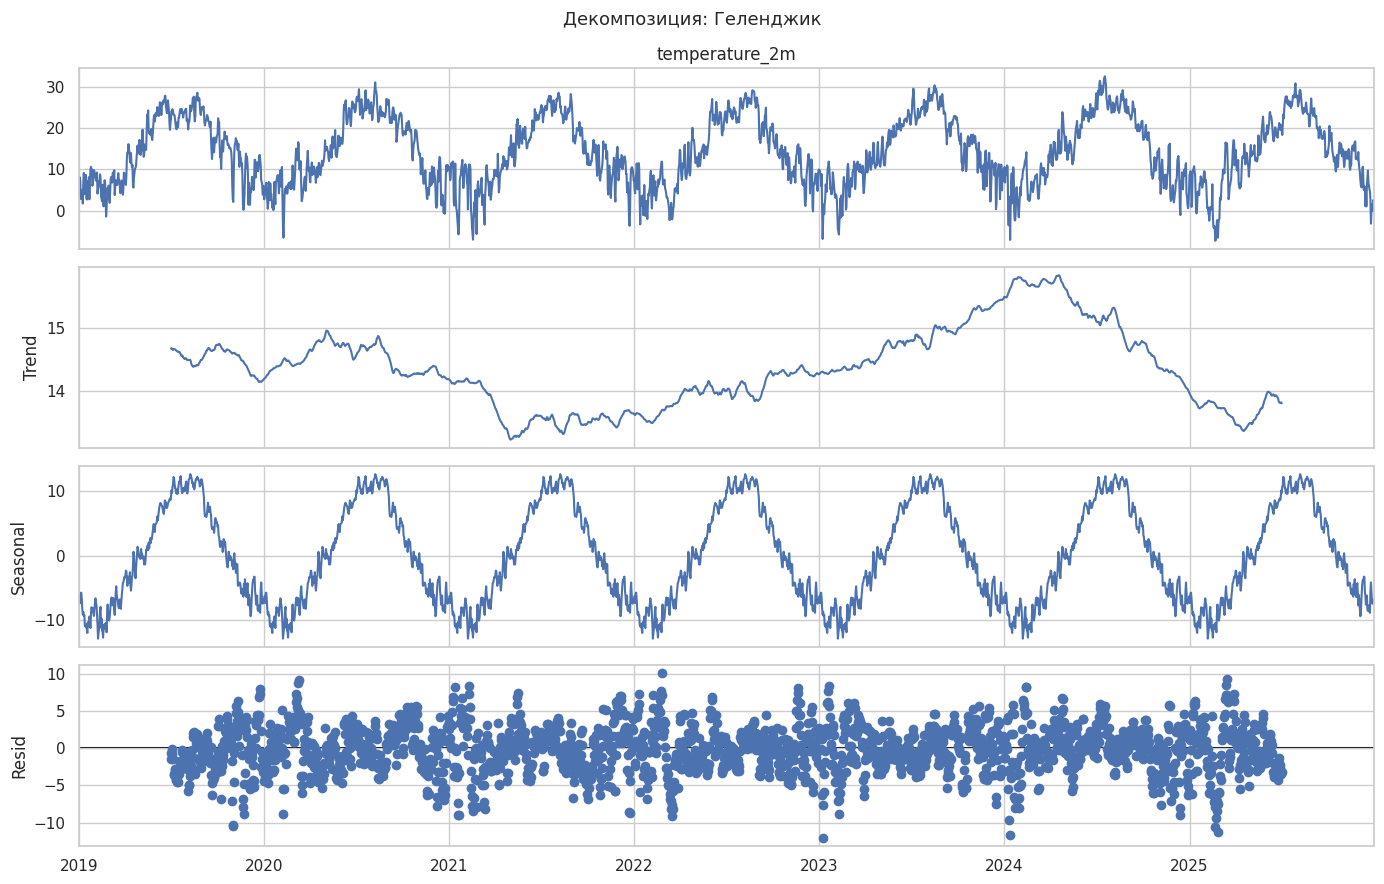

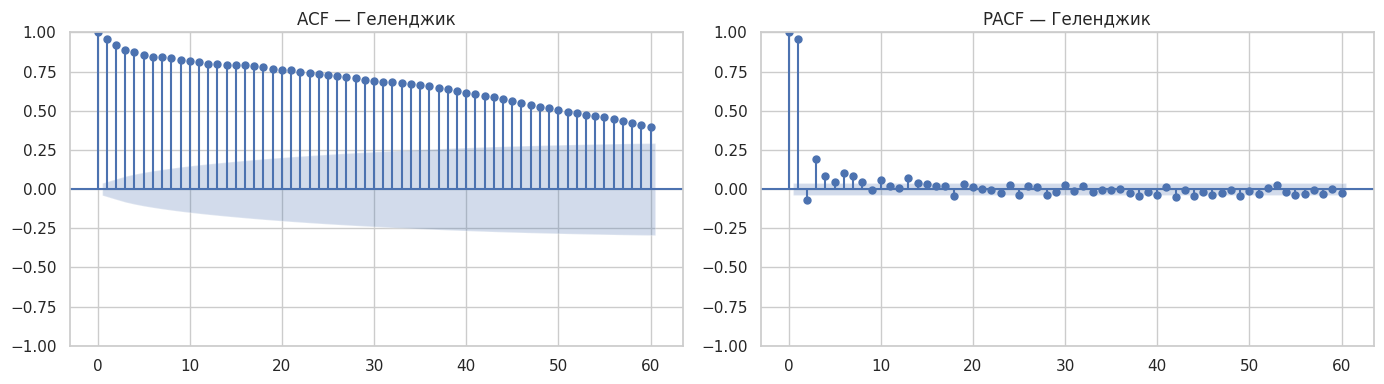


  Город: Москва  |  записей: 2557
ADF = -3.1561  |  p-value = 2.2671e-02  =>  СТАЦИОНАРЕН ✅
  Крит. значение 1%: -3.4329
  Крит. значение 5%: -2.8627
  Крит. значение 10%: -2.5674


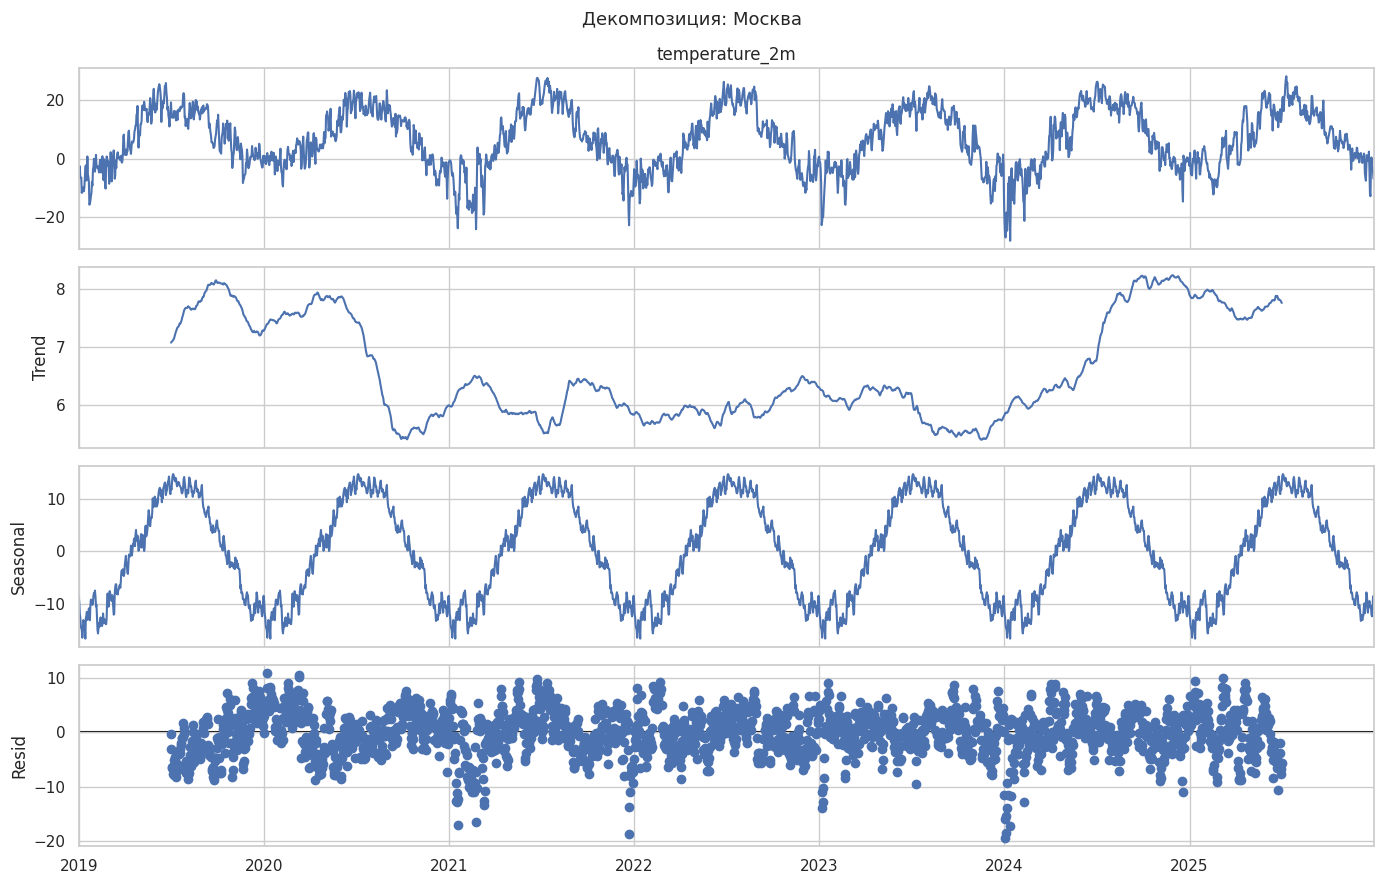

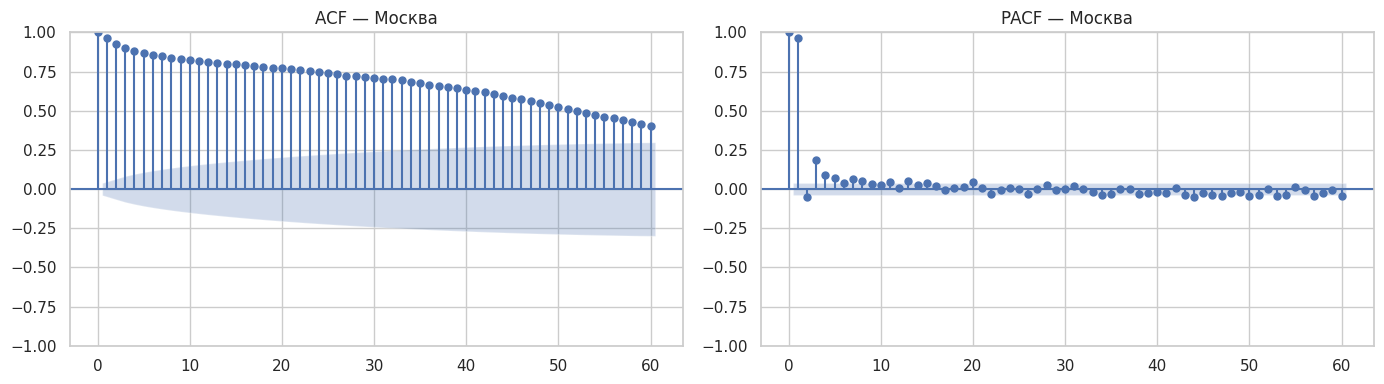


  Город: Находка  |  записей: 2557
ADF = -2.3537  |  p-value = 1.5522e-01  =>  НЕСТАЦИОНАРЕН ⚠️
  Крит. значение 1%: -3.4329
  Крит. значение 5%: -2.8627
  Крит. значение 10%: -2.5674


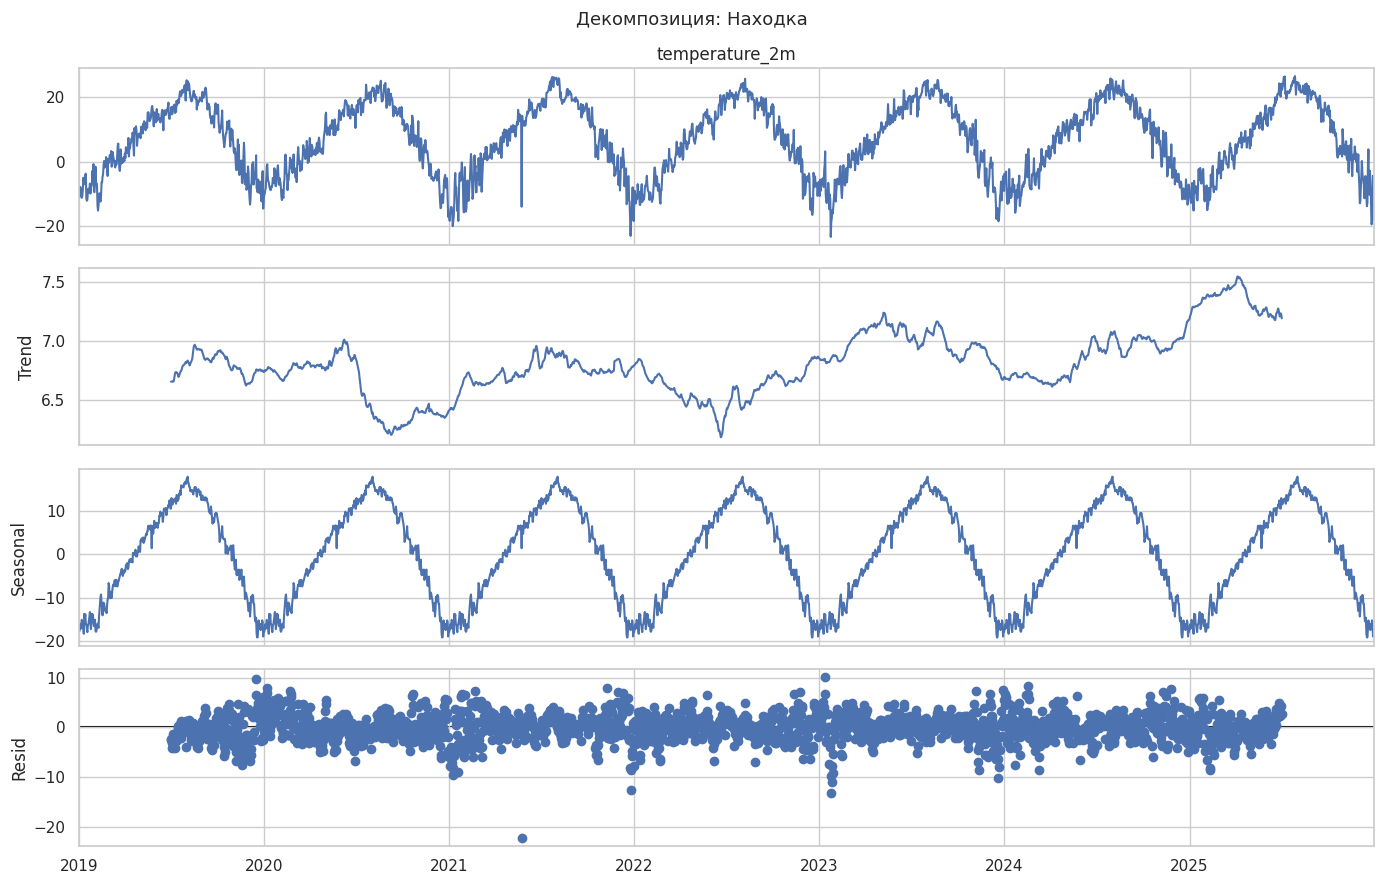

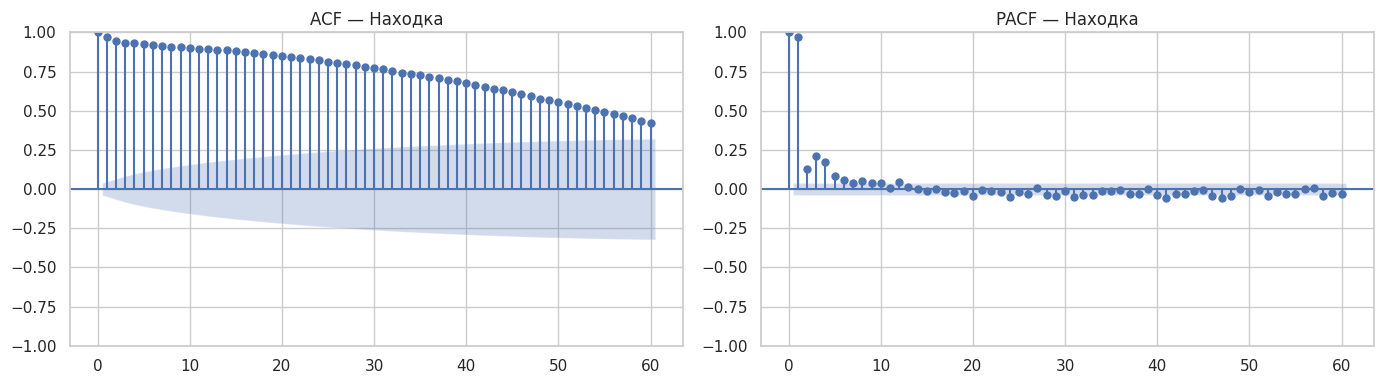


  Город: Санкт-Петербург  |  записей: 2557
ADF = -3.1834  |  p-value = 2.0966e-02  =>  СТАЦИОНАРЕН ✅
  Крит. значение 1%: -3.4329
  Крит. значение 5%: -2.8627
  Крит. значение 10%: -2.5674


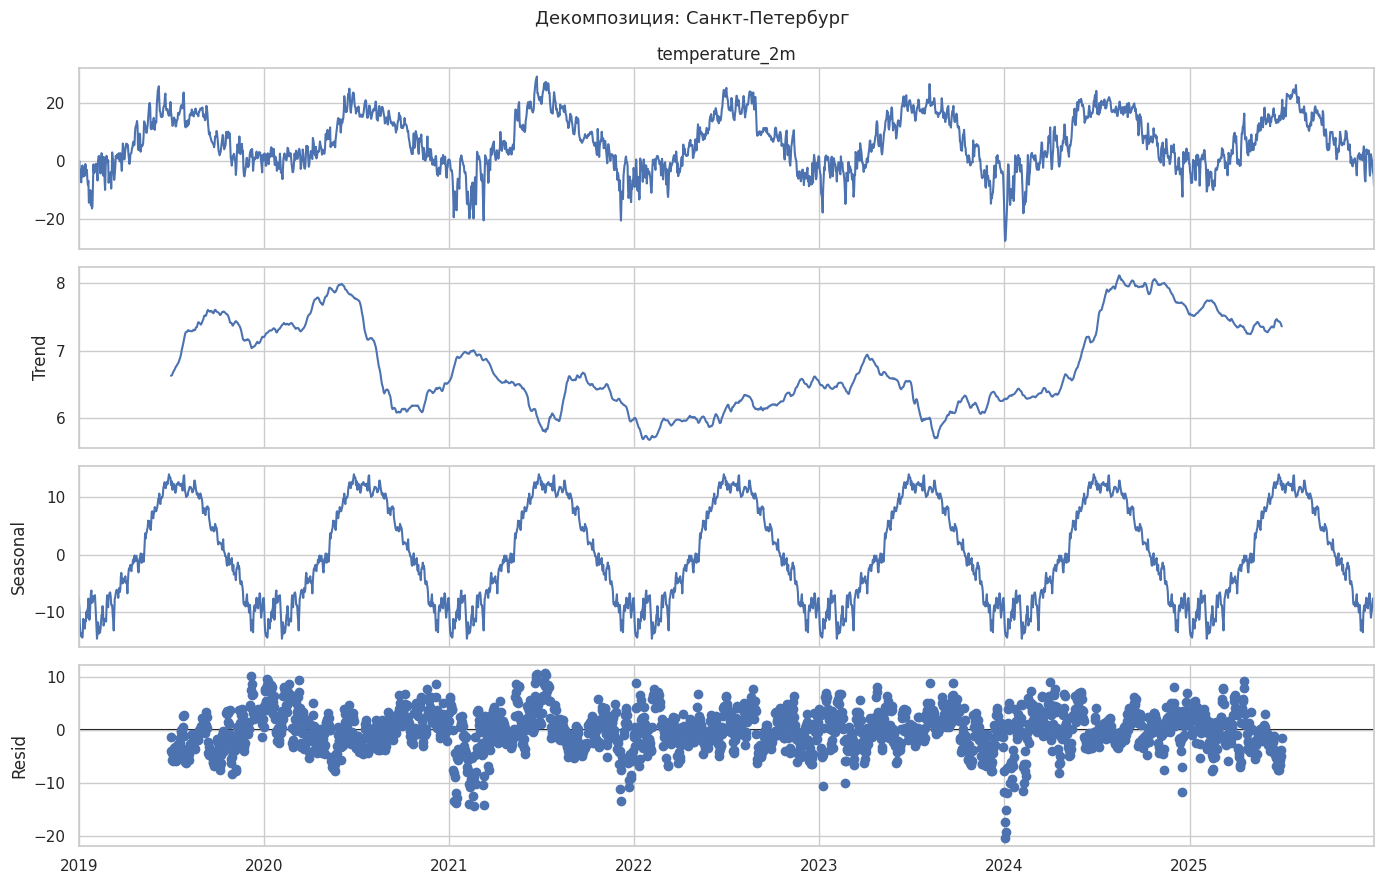

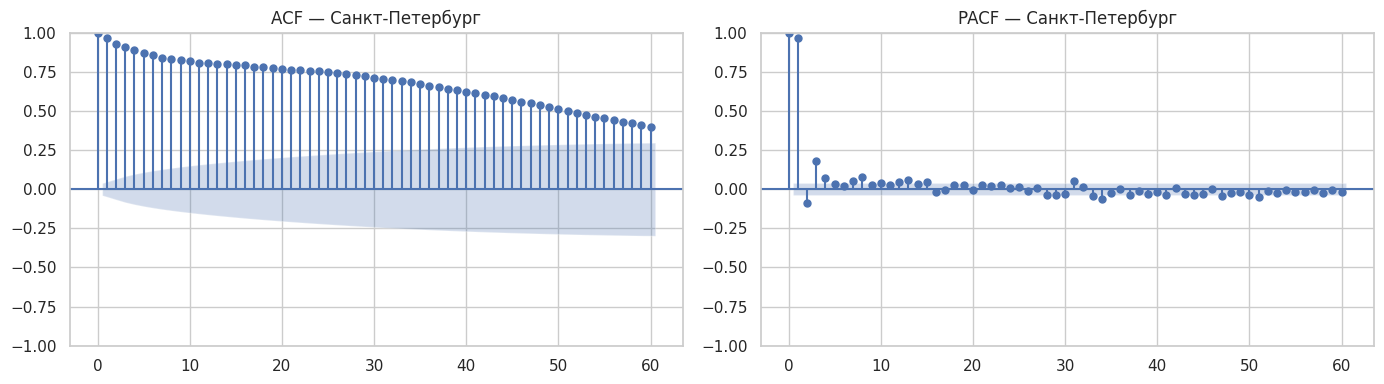


  Город: Сочи  |  записей: 2557
ADF = -3.0077  |  p-value = 3.4180e-02  =>  СТАЦИОНАРЕН ✅
  Крит. значение 1%: -3.4329
  Крит. значение 5%: -2.8627
  Крит. значение 10%: -2.5674


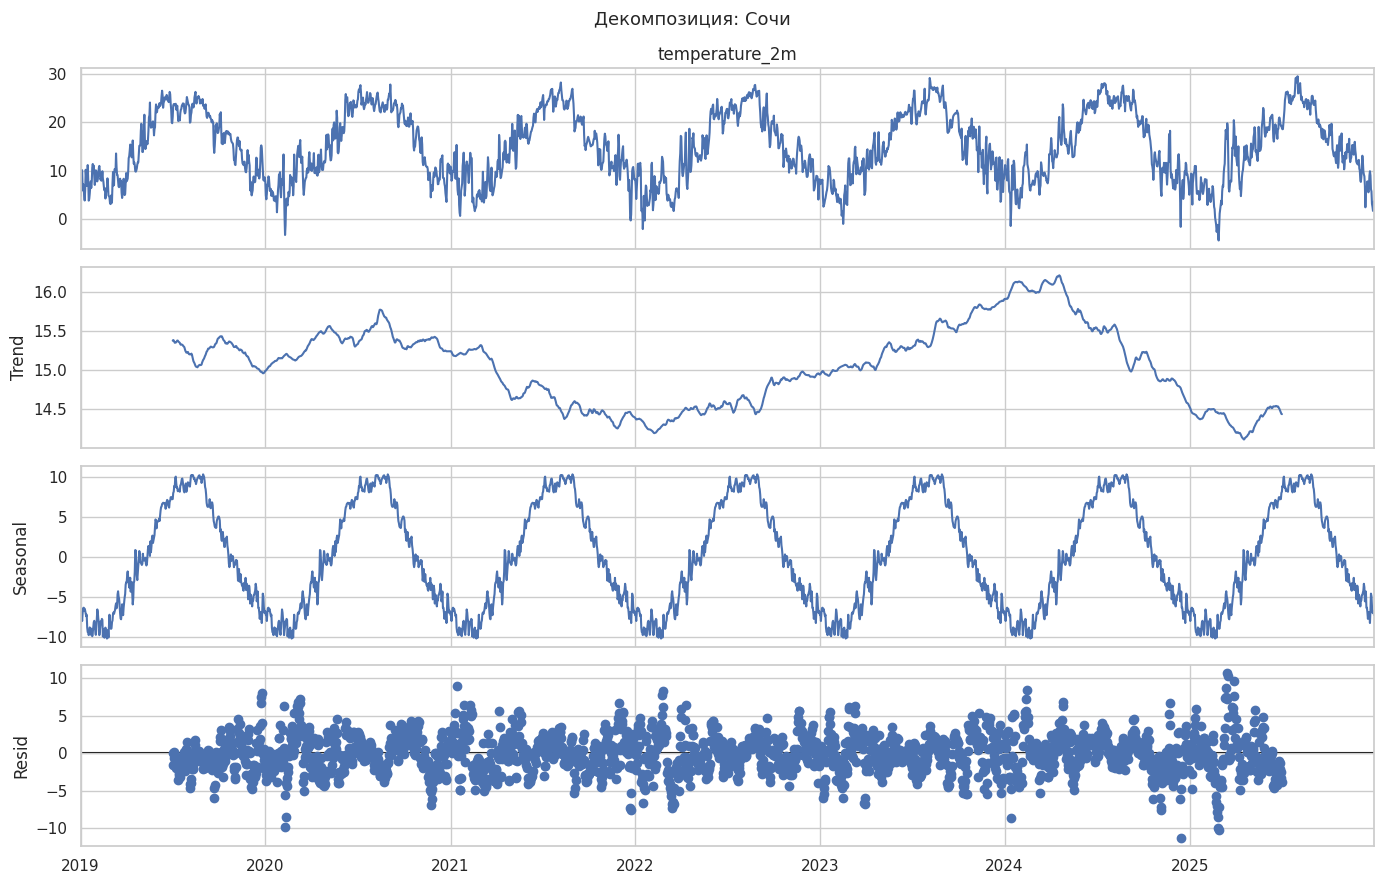

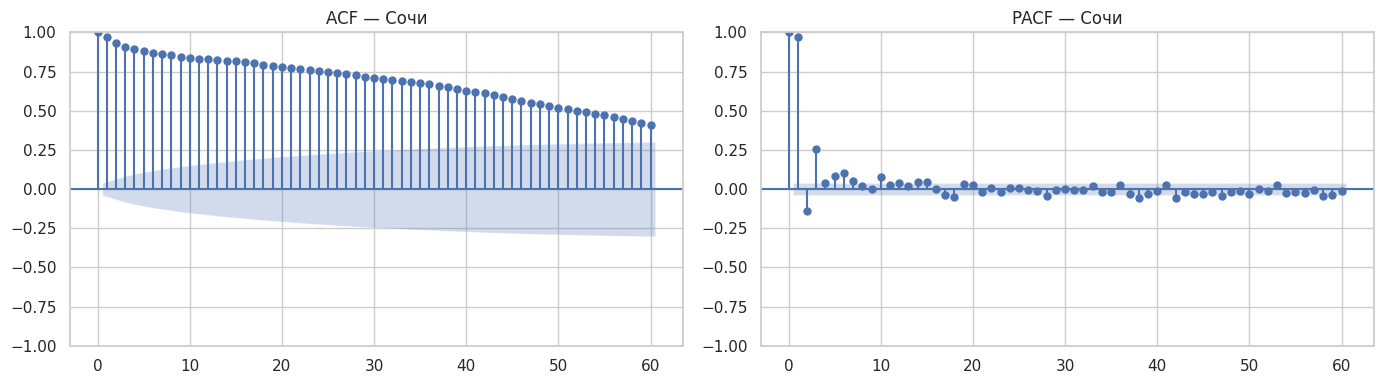

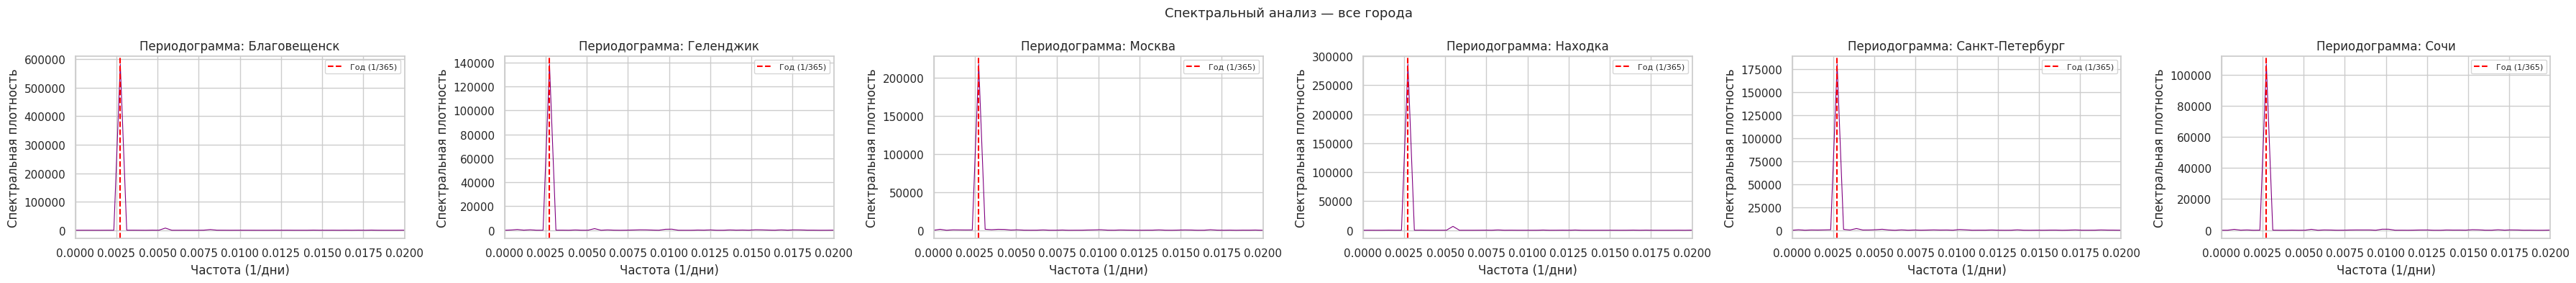


=== Итог по стационарности ===
  Стационарны   (p<0.05): ['Благовещенск', 'Геленджик', 'Москва', 'Санкт-Петербург', 'Сочи']
  Нестационарны (p≥0.05): ['Находка']
  ⚠️  Находка — ряд имеет признаки нестационарности.
  Для прогнозирования деревьями это не критично: модели работают с лагами
  и календарными признаками, а не требуют явной стационарности.

Во всех городах выражена годовая сезонность (пик на частоте 1/365 в периодограмме).


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import periodogram

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

cities = sorted(full_df['city'].unique())
print(f"Города в датасете: {cities}\n")

# ── Дневной ресемплинг для каждого города ─────────────────────────────────
daily_by_city = {}
for city in cities:
    sub = full_df[full_df['city'] == city][['temperature_2m']].copy()
    daily_by_city[city] = sub.resample('D').mean()

# ── 1. Совместный график всех городов ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
for city, df_d in daily_by_city.items():
    ax.plot(df_d.index, df_d['temperature_2m'], label=city, linewidth=0.9, alpha=0.85)
ax.set_title('Среднесуточная температура по всем городам (2019–2025)')
ax.set_xlabel('Дата'); ax.set_ylabel('Температура (°C)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# ── 2. Для каждого города: ADF + декомпозиция + ACF/PACF ──────────────────
for city, df_d in daily_by_city.items():
    series = df_d['temperature_2m'].dropna()

    print(f"{'='*60}")
    print(f"  Город: {city}  |  записей: {len(series)}")
    print(f"{'='*60}")

    # ADF-тест на стационарность
    adf_stat, p_val, _, _, crit_vals, _ = adfuller(series)
    verdict = 'СТАЦИОНАРЕН ✅' if p_val < 0.05 else 'НЕСТАЦИОНАРЕН ⚠️'
    print(f"ADF = {adf_stat:.4f}  |  p-value = {p_val:.4e}  =>  {verdict}")
    for k, v in crit_vals.items():
        print(f"  Крит. значение {k}: {v:.4f}")

    # Декомпозиция (годовая сезонность)
    decomp = seasonal_decompose(series, model='additive', period=365)
    fig = decomp.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle(f'Декомпозиция: {city}', fontsize=13)
    fig.tight_layout(); plt.show()

    # ACF + PACF (помогают выбрать размер окна признаков)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series, lags=60, ax=axes[0], title=f'ACF — {city}')
    plot_pacf(series, lags=60, ax=axes[1], title=f'PACF — {city}', method='ywm')
    plt.tight_layout(); plt.show()

    print()

# ── 3. Спектральный анализ для всех городов ───────────────────────────────
fig, axes = plt.subplots(1, len(cities), figsize=(6 * len(cities), 4))
if len(cities) == 1:
    axes = [axes]
for ax, (city, df_d) in zip(axes, daily_by_city.items()):
    freqs, power = periodogram(df_d['temperature_2m'].dropna())
    ax.plot(freqs, power, color='purple', linewidth=0.8)
    ax.axvline(1/365.25, color='red', linestyle='--', label='Год (1/365)')
    ax.set_xlim(0, 0.02)
    ax.set_title(f'Периодограмма: {city}')
    ax.set_xlabel('Частота (1/дни)'); ax.set_ylabel('Спектральная плотность')
    ax.legend(fontsize=8)
plt.suptitle('Спектральный анализ — все города', fontsize=13)
plt.tight_layout(); plt.show()

# Собираем итог по стационарности
adf_results = {}
for city_name, df_d in daily_by_city.items():
    s = df_d['temperature_2m'].dropna()
    _, p, *_ = adfuller(s)
    adf_results[city_name] = p

print("\n=== Итог по стационарности ===")
non_stationary = [c for c, p in adf_results.items() if p >= 0.05]
stationary     = [c for c, p in adf_results.items() if p <  0.05]
print(f"  Стационарны   (p<0.05): {stationary}")
print(f"  Нестационарны (p≥0.05): {non_stationary}")
if non_stationary:
    print(f"  ⚠️  {', '.join(non_stationary)} — ряд имеет признаки нестационарности.")
    print("  Для прогнозирования деревьями это не критично: модели работают с лагами")
    print("  и календарными признаками, а не требуют явной стационарности.")
else:
    print("  ✅ Все ряды стационарны по тесту ADF.")
print("\nВо всех городах выражена годовая сезонность (пик на частоте 1/365 в периодограмме).")


In [6]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("=== Feature Engineering (все города) ===\n")

WINDOW  = 14   # размер окна лагов (обоснован ACF/PACF — значимая автокорреляция до ~14 дней)
HORIZON = 7    # горизонт прогноза — 1 неделя

def make_features(df_daily, city_name, window=WINDOW, horizon=HORIZON):
    """
    Принимает дневной ряд температуры одного города (DatetimeIndex, колонка temperature_2m).
    Возвращает датафрейм с признаками и целевыми переменными (target_h1 … target_h7).
    """
    df = df_daily.copy()
    df.columns = ['temperature_2m']

    # 1. Календарные признаки
    df['dayofyear']  = df.index.dayofyear
    df['month']      = df.index.month
    df['dayofweek']  = df.index.dayofweek

    # 2. Фурье-признаки для годовой сезонности (непрерывное кодирование)
    df['sin_doy'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['cos_doy'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

    # 3. Лаговые признаки (авторегрессия)
    for i in range(1, window + 1):
        df[f'lag_{i}'] = df['temperature_2m'].shift(i)

    # 4. Скользящие статистики (только по уже известным значениям — shift(1))
    for w in [3, 7, 14]:
        base = df['temperature_2m'].shift(1)
        df[f'roll_mean_{w}'] = base.rolling(w).mean()
        df[f'roll_std_{w}']  = base.rolling(w).std()
        df[f'roll_min_{w}']  = base.rolling(w).min()
        df[f'roll_max_{w}']  = base.rolling(w).max()

    # 5. Разностные признаки (скорость изменения)
    df['diff_1'] = df['temperature_2m'].shift(1).diff(1)
    df['diff_7'] = df['temperature_2m'].shift(1).diff(7)

    # 6. Целевые переменные для Direct-стратегии
    for h in range(1, horizon + 1):
        df[f'target_h{h}'] = df['temperature_2m'].shift(-h)

    df['city'] = city_name
    return df.dropna()

# Создаём признаки для ВСЕХ городов и объединяем
all_feats = [make_features(df_d, city) for city, df_d in daily_by_city.items()]
df_model = pd.concat(all_feats).sort_index()

# Кодируем город числом — деревья работают с этим корректно
le = LabelEncoder()
df_model['city_enc'] = le.fit_transform(df_model['city'])
print("Коды городов:")
for name, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {name} -> {code}")

# ── Хронологическое разделение: Train / Val / Test ────────────────────────
TARGET_COLS  = [f'target_h{h}' for h in range(1, HORIZON + 1)]
# temperature_2m — текущее (t=0) значение температуры, допустимо как признак
# при прогнозе на t+1...t+7 (утечки данных нет: мы знаем сегодняшнюю температуру)
FEATURE_COLS = [c for c in df_model.columns if c not in TARGET_COLS + ['city']]

train = df_model.loc['2019-01-01':'2023-12-31']
val   = df_model.loc['2024-01-01':'2024-12-31']
test  = df_model.loc['2025-01-01':'2025-12-31']

X_train, y_train = train[FEATURE_COLS], train[TARGET_COLS]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET_COLS]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COLS]

print(f"\nTrain: {X_train.shape}  [{train.index.min().date()} — {train.index.max().date()}]")
print(f"Val:   {X_val.shape}  [{val.index.min().date()} — {val.index.max().date()}]")
print(f"Test:  {X_test.shape}  [{test.index.min().date()} — {test.index.max().date()}]")
print(f"\nПризнаков: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


=== Feature Engineering (все города) ===

Коды городов:
  Благовещенск -> 0
  Геленджик -> 1
  Москва -> 2
  Находка -> 3
  Санкт-Петербург -> 4
  Сочи -> 5

Train: (10872, 35)  [2019-01-15 — 2023-12-31]
Val:   (2196, 35)  [2024-01-01 — 2024-12-31]
Test:  (2148, 35)  [2025-01-01 — 2025-12-24]

Признаков: 35
['temperature_2m', 'dayofyear', 'month', 'dayofweek', 'sin_doy', 'cos_doy', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'roll_mean_3', 'roll_std_3', 'roll_min_3', 'roll_max_3', 'roll_mean_7', 'roll_std_7', 'roll_min_7', 'roll_max_7', 'roll_mean_14', 'roll_std_14', 'roll_min_14', 'roll_max_14', 'diff_1', 'diff_7', 'city_enc']


In [7]:
!pip install optuna lightgbm -q

import optuna
import warnings
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=== Подбор гиперпараметров через Optuna ===")
print("Оптимизация по MAE на Val-выборке (горизонт h=1)\n")

y_tr1 = y_train['target_h1']
y_v1  = y_val['target_h1']

# ── 1. Decision Tree ──────────────────────────────────────────────────────
def obj_dt(trial):
    p = dict(
        max_depth=trial.suggest_int('max_depth', 3, 15),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 30),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
        random_state=42,
    )
    m = DecisionTreeRegressor(**p)
    m.fit(X_train, y_tr1)
    return mean_absolute_error(y_v1, m.predict(X_val))

study_dt = optuna.create_study(direction='minimize')
study_dt.optimize(obj_dt, n_trials=30, show_progress_bar=True)
best_dt = {**study_dt.best_params, 'random_state': 42}
print(f"\n🌲 Decision Tree — лучшие параметры: {best_dt}")
print(f"   MAE val = {study_dt.best_value:.3f}°C")

# ── 2. Random Forest ─────────────────────────────────────────────────────
def obj_rf(trial):
    p = dict(
        n_estimators=trial.suggest_int('n_estimators', 50, 300, step=50),
        max_depth=trial.suggest_int('max_depth', 5, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 15),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        random_state=42, n_jobs=-1,
    )
    m = RandomForestRegressor(**p)
    m.fit(X_train, y_tr1)
    return mean_absolute_error(y_v1, m.predict(X_val))

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(obj_rf, n_trials=20, show_progress_bar=True)
best_rf = {**study_rf.best_params, 'random_state': 42, 'n_jobs': -1}
print(f"\n🌳 Random Forest — лучшие параметры: {best_rf}")
print(f"   MAE val = {study_rf.best_value:.3f}°C")

# ── 3. LightGBM ──────────────────────────────────────────────────────────
def obj_lgb(trial):
    p = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        num_leaves=trial.suggest_int('num_leaves', 15, 63),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 50),
        subsample=trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.7, 1.0),
        random_state=42, verbose=-1,
    )
    m = LGBMRegressor(**p)
    m.fit(X_train, y_tr1)
    return mean_absolute_error(y_v1, m.predict(X_val))

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(obj_lgb, n_trials=30, show_progress_bar=True)
best_lgb = {**study_lgb.best_params, 'random_state': 42, 'verbose': -1}
print(f"\n🚀 LightGBM — лучшие параметры: {best_lgb}")
print(f"   MAE val = {study_lgb.best_value:.3f}°C")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00
=== Подбор гиперпараметров через Optuna ===
Оптимизация по MAE на Val-выборке (горизонт h=1)



  0%|          | 0/30 [00:00<?, ?it/s]


🌲 Decision Tree — лучшие параметры: {'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 3, 'random_state': 42}
   MAE val = 1.893°C


  0%|          | 0/20 [00:00<?, ?it/s]


🌳 Random Forest — лучшие параметры: {'n_estimators': 250, 'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 3, 'random_state': 42, 'n_jobs': -1}
   MAE val = 1.798°C


  0%|          | 0/30 [00:00<?, ?it/s]


🚀 LightGBM — лучшие параметры: {'n_estimators': 150, 'learning_rate': 0.041707868649119594, 'max_depth': 8, 'num_leaves': 32, 'min_child_samples': 25, 'subsample': 0.9195355641309024, 'colsample_bytree': 0.9479244717660636, 'random_state': 42, 'verbose': -1}
   MAE val = 1.796°C


In [8]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

print("=== Direct vs Recursive — полная оценка на тесте ===\n")

# ── Функция метрик ────────────────────────────────────────────────────────
def calc_metrics(y_true, y_pred, y_prev):
    """
    MAE, MAPE, WAPE, Directional Accuracy, Directional R2.
    y_prev — значение температуры в момент t (лаг 1), используется как baseline
    для метрик направления.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_prev = np.asarray(y_prev, dtype=float)

    mae  = mean_absolute_error(y_true, y_pred)

    nz   = y_true != 0
    mape = float(np.mean(np.abs((y_true[nz] - y_pred[nz]) / y_true[nz]))) if nz.any() else np.nan

    denom_wape = np.sum(np.abs(y_true))
    wape = float(np.sum(np.abs(y_true - y_pred)) / denom_wape) if denom_wape > 0 else np.nan

    td = y_true - y_prev
    pd_ = y_pred - y_prev
    dir_acc = float(np.mean(np.sign(td) == np.sign(pd_)))

    ss_res = np.sum((td - pd_) ** 2)
    ss_tot = np.sum((td - np.mean(td)) ** 2)
    dir_r2  = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    return {'MAE': round(mae, 3), 'MAPE': round(mape, 4),
            'WAPE': round(wape, 4), 'Dir_Acc': round(dir_acc, 3),
            'Dir_R2': round(dir_r2, 3)}

# ── Инициализация моделей с лучшими параметрами от Optuna ─────────────────
MODELS = {
    'Decision Tree': DecisionTreeRegressor(**best_dt),
    'Random Forest': RandomForestRegressor(**best_rf),
    'LightGBM':      LGBMRegressor(**best_lgb),
}

# y_baseline — «сегодняшняя» температура (lag_1) для расчёта направления
y_prev_test = test['lag_1'].values

results = []

for model_name, model in MODELS.items():
    print(f"Обучение: {model_name} ...")

    # ══════════════════════════════════════════
    #  DIRECT STRATEGY
    #  Для каждого горизонта — отдельная модель
    # ══════════════════════════════════════════
    for h in range(1, HORIZON + 1):
        m = type(model)(**model.get_params())
        m.fit(X_train, train[f'target_h{h}'])
        preds = m.predict(X_test)
        metrics = calc_metrics(test[f'target_h{h}'], preds, y_prev_test)
        results.append({'Model': model_name, 'Strategy': 'Direct', 'Horizon': h, **metrics})

    # ══════════════════════════════════════════
    #  RECURSIVE STRATEGY
    #  Одна модель на h=1, цепочка прогнозов
    # ══════════════════════════════════════════
    m_rec = type(model)(**model.get_params())
    m_rec.fit(X_train, y_train['target_h1'])

    X_rec = X_test.copy()

    for h in range(1, HORIZON + 1):
        preds_rec = m_rec.predict(X_rec)
        metrics = calc_metrics(test[f'target_h{h}'], preds_rec, y_prev_test)
        results.append({'Model': model_name, 'Strategy': 'Recursive', 'Horizon': h, **metrics})

        if h < HORIZON:
            # Сдвигаем лаги: lag_14 <- lag_13 <- ... <- lag_2 <- lag_1 <- pred
            for i in range(WINDOW - 1, 0, -1):
                X_rec[f'lag_{i+1}'] = X_rec[f'lag_{i}'].values
            X_rec['lag_1'] = preds_rec

df_results = pd.DataFrame(results)

# ── Сводная таблица MAE по горизонтам для каждой модели ───────────────────
print("\n=== MAE по горизонтам (Direct | Recursive) ===\n")
for model_name in MODELS:
    sub = df_results[df_results['Model'] == model_name]
    pivot = sub.pivot(index='Horizon', columns='Strategy', values='MAE')
    print(f"  {model_name}:")
    display(pivot)

print("\n=== Полная таблица метрик ===")
display(df_results.sort_values(['Model', 'Strategy', 'Horizon']).reset_index(drop=True))


=== Direct vs Recursive — полная оценка на тесте ===

Обучение: Decision Tree ...
Обучение: Random Forest ...
Обучение: LightGBM ...

=== MAE по горизонтам (Direct | Recursive) ===

  Decision Tree:


Strategy,Direct,Recursive
Horizon,,
1,1.825,1.825
2,2.539,2.503
3,2.839,2.841
4,3.070,3.063
5,3.218,3.330
6,3.342,3.528
7,3.391,3.659


  Random Forest:


Strategy,Direct,Recursive
Horizon,,
1,1.721,1.721
2,2.441,2.381
3,2.741,2.715
4,2.885,2.935
5,3.014,3.193
6,3.087,3.384
7,3.120,3.517


  LightGBM:


Strategy,Direct,Recursive
Horizon,,
1,1.706,1.706
2,2.390,2.325
3,2.639,2.645
4,2.774,2.861
5,2.887,3.092
6,2.990,3.280
7,3.020,3.403



=== Полная таблица метрик ===


,Model,Strategy,Horizon,MAE,MAPE,WAPE,Dir_Acc,Dir_R2
0,Decision Tree,Direct,1,1.825,0.6787,0.1485,0.730,0.448
1,Decision Tree,Direct,2,2.539,1.1037,0.2067,0.662,0.206
2,Decision Tree,Direct,3,2.839,2.0494,0.2312,0.642,0.176
3,Decision Tree,Direct,4,3.070,2.5029,0.2504,0.655,0.166
4,Decision Tree,Direct,5,3.218,3.5246,0.2626,0.669,0.198
5,Decision Tree,Direct,6,3.342,3.7985,0.2727,0.663,0.204
6,Decision Tree,Direct,7,3.391,3.1768,0.2766,0.682,0.206
7,Decision Tree,Recursive,1,1.825,0.6787,0.1485,0.730,0.448
8,Decision Tree,Recursive,2,2.503,0.9365,0.2037,0.657,0.212
9,Decision Tree,Recursive,3,2.841,1.9350,0.2314,0.638,0.142


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


=== Визуализация прогнозов и анализ остатков ===

Лучшая модель по MAE (h=1, Direct): LightGBM  MAE=1.706°C


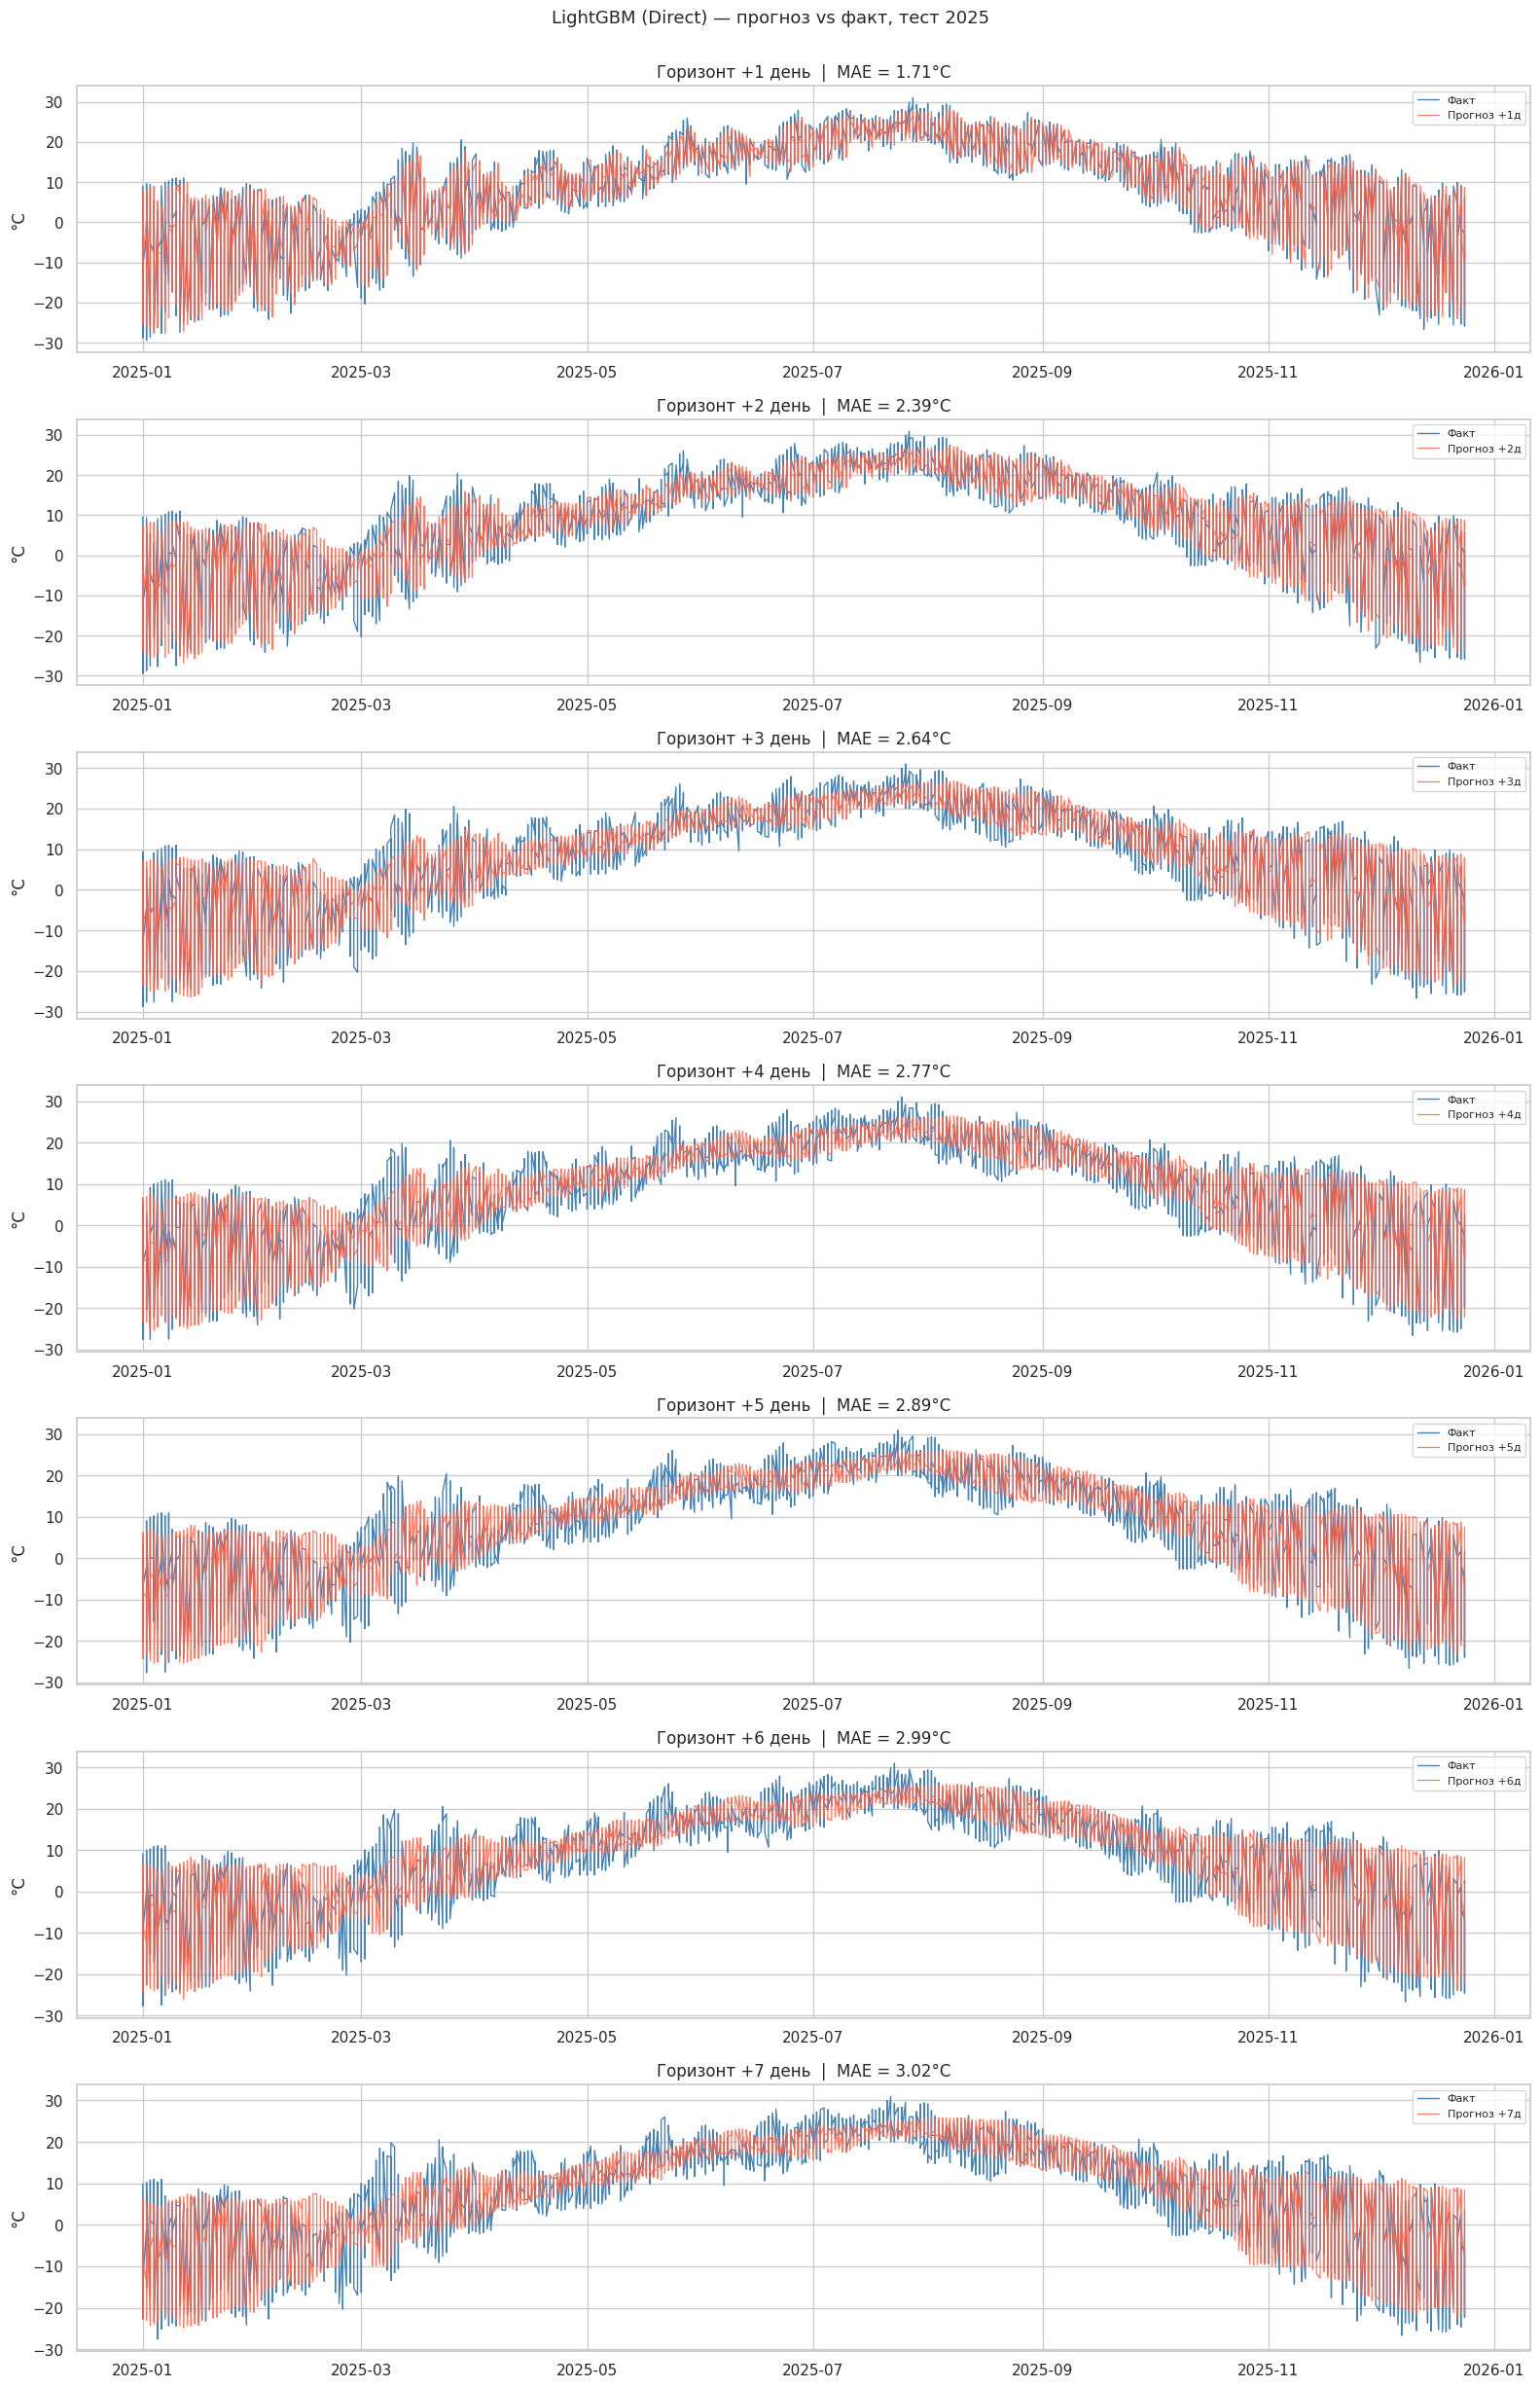

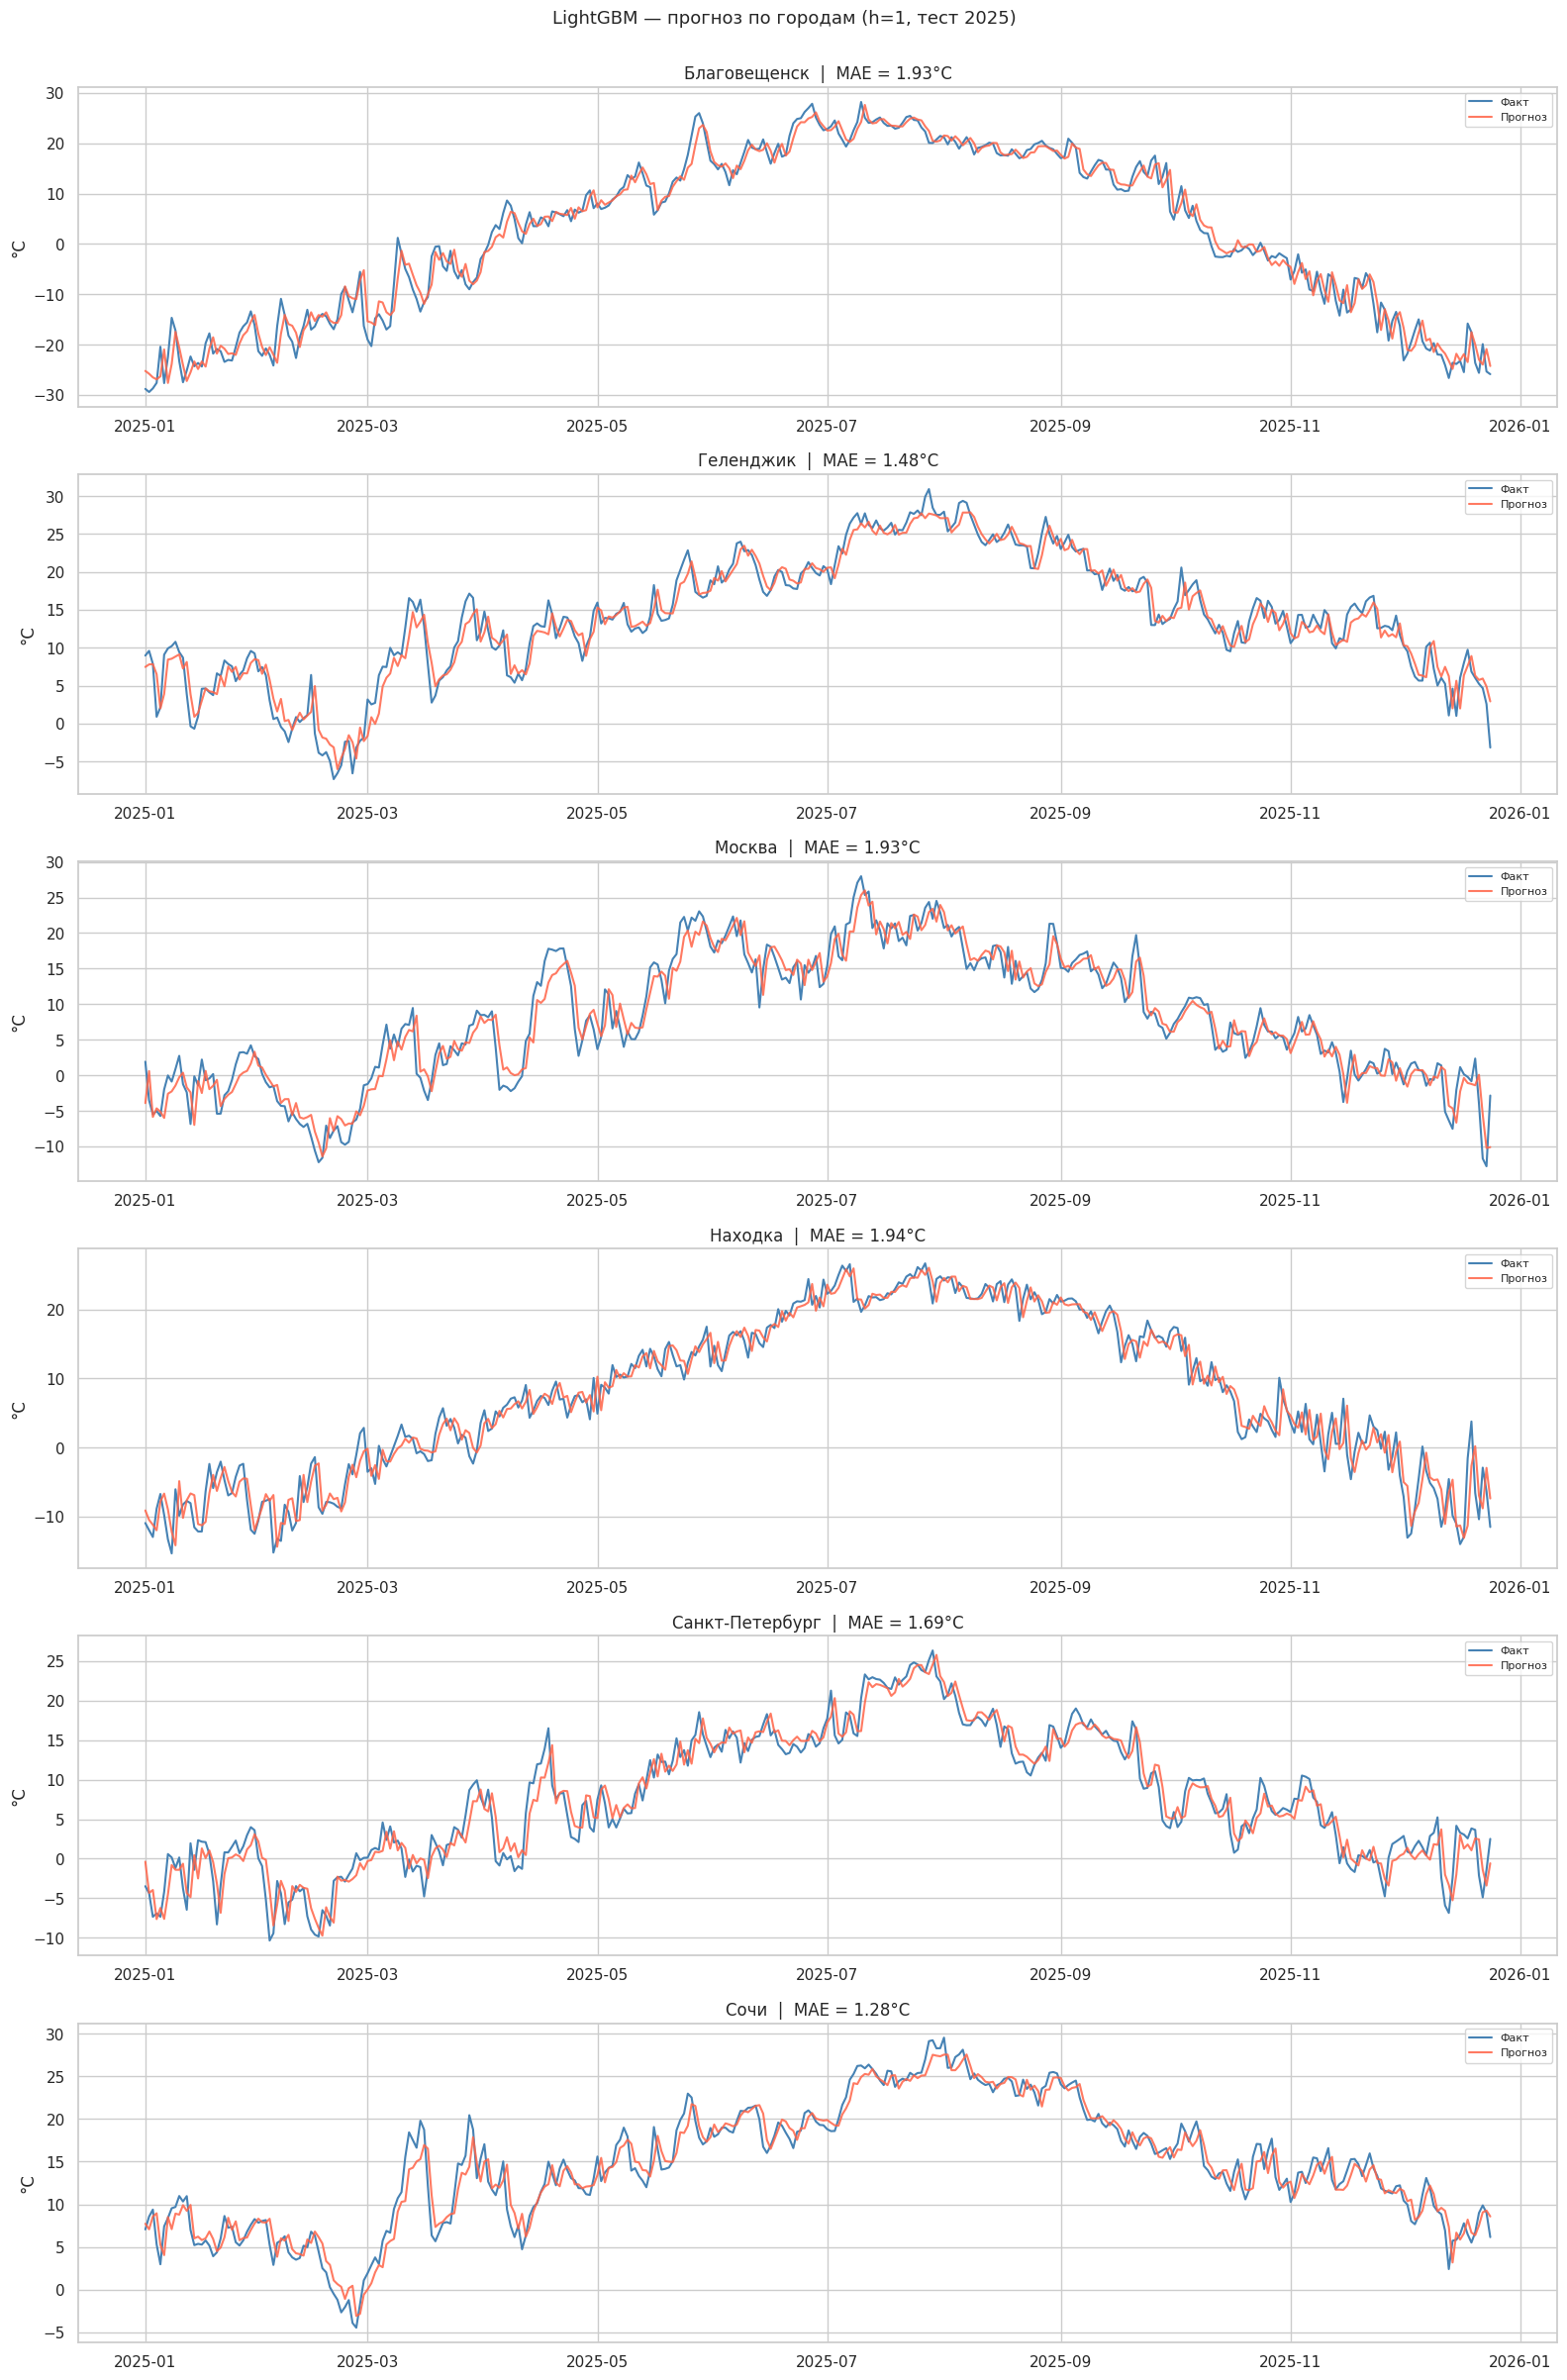

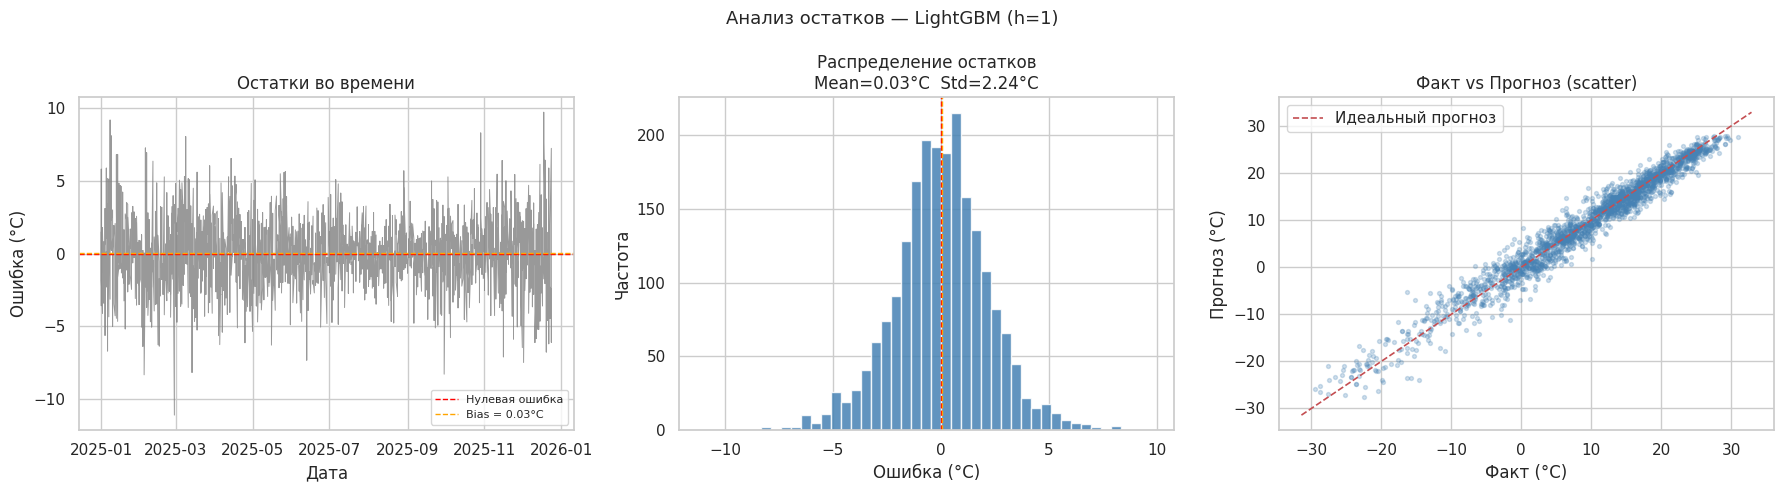

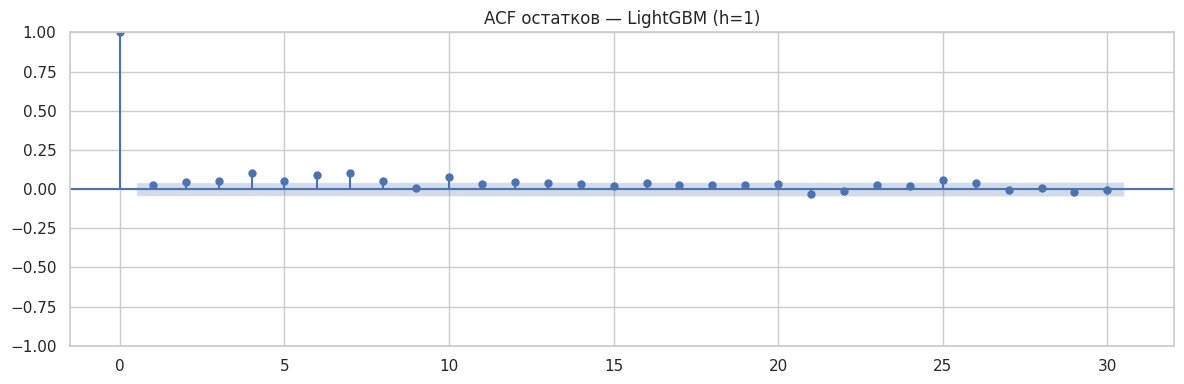


Среднее остатков (bias):       +0.029°C
Стд. откл. остатков:            2.240°C
Макс. абсолютная ошибка:        11.095°C
✅ Систематического смещения нет (|bias| < 0.3°C)


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf

print("=== Визуализация прогнозов и анализ остатков ===\n")

# ── Выбираем лучшую модель (Direct, h=1) по MAE ───────────────────────────
best_row = (df_results[(df_results['Strategy'] == 'Direct') & (df_results['Horizon'] == 1)]
            .sort_values('MAE').iloc[0])
BEST_MODEL_NAME = best_row['Model']
print(f"Лучшая модель по MAE (h=1, Direct): {BEST_MODEL_NAME}  MAE={best_row['MAE']}°C")

# Переобучаем лучшую модель для всех горизонтов (Direct)
BestCls    = type(MODELS[BEST_MODEL_NAME])
best_preds = {}
for h in range(1, HORIZON + 1):
    m = BestCls(**MODELS[BEST_MODEL_NAME].get_params())
    m.fit(X_train, train[f'target_h{h}'])
    best_preds[h] = m.predict(X_test)

# ── 1. Прогноз vs Факт для каждого горизонта ─────────────────────────────
fig, axes = plt.subplots(HORIZON, 1, figsize=(16, 3.5 * HORIZON))
for h, ax in zip(range(1, HORIZON + 1), axes):
    y_true_h = test[f'target_h{h}'].values
    y_pred_h = best_preds[h]
    mae_h = mean_absolute_error(y_true_h, y_pred_h)
    ax.plot(test.index, y_true_h, label='Факт',    color='steelblue', linewidth=1.0)
    ax.plot(test.index, y_pred_h, label=f'Прогноз +{h}д', color='tomato',    linewidth=0.9, alpha=0.85)
    ax.set_title(f'Горизонт +{h} день  |  MAE = {mae_h:.2f}°C')
    ax.set_ylabel('°C'); ax.legend(loc='upper right', fontsize=8)
fig.suptitle(f'{BEST_MODEL_NAME} (Direct) — прогноз vs факт, тест 2025', fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

# ── 2. Прогноз по городам (h=1) ───────────────────────────────────────────
m_h1 = BestCls(**MODELS[BEST_MODEL_NAME].get_params())
m_h1.fit(X_train, y_train['target_h1'])

fig, axes = plt.subplots(len(cities), 1, figsize=(16, 4 * len(cities)))
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, sorted(cities)):
    mask = test['city'] == city
    if mask.sum() == 0:
        continue
    y_true_c = test.loc[mask, 'target_h1'].values
    y_pred_c = m_h1.predict(X_test[mask])
    mae_c = mean_absolute_error(y_true_c, y_pred_c)
    ax.plot(test[mask].index, y_true_c, label='Факт',    color='steelblue')
    ax.plot(test[mask].index, y_pred_c, label='Прогноз', color='tomato', alpha=0.85)
    ax.set_title(f'{city}  |  MAE = {mae_c:.2f}°C')
    ax.set_ylabel('°C'); ax.legend(fontsize=8)
fig.suptitle(f'{BEST_MODEL_NAME} — прогноз по городам (h=1, тест 2025)', fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

# ── 3. Анализ остатков (h=1) ──────────────────────────────────────────────
residuals = test['target_h1'].values - best_preds[1]
bias = residuals.mean()
std  = residuals.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Остатки во времени
axes[0].plot(test.index, residuals, color='gray', linewidth=0.7, alpha=0.8)
axes[0].axhline(0,    color='red',    linestyle='--', linewidth=1, label='Нулевая ошибка')
axes[0].axhline(bias, color='orange', linestyle='--', linewidth=1, label=f'Bias = {bias:.2f}°C')
axes[0].set_title('Остатки во времени')
axes[0].set_xlabel('Дата'); axes[0].set_ylabel('Ошибка (°C)'); axes[0].legend(fontsize=8)

# Гистограмма
axes[1].hist(residuals, bins=45, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0,    color='red',    linestyle='--', linewidth=1)
axes[1].axvline(bias, color='orange', linestyle='--', linewidth=1)
axes[1].set_title(f'Распределение остатков\nMean={bias:.2f}°C  Std={std:.2f}°C')
axes[1].set_xlabel('Ошибка (°C)'); axes[1].set_ylabel('Частота')

# Scatter факт vs прогноз
lo = min(test['target_h1'].min(), best_preds[1].min()) - 2
hi = max(test['target_h1'].max(), best_preds[1].max()) + 2
axes[2].scatter(test['target_h1'].values, best_preds[1], alpha=0.25, s=8, color='steelblue')
axes[2].plot([lo, hi], [lo, hi], 'r--', linewidth=1.2, label='Идеальный прогноз')
axes[2].set_xlabel('Факт (°C)'); axes[2].set_ylabel('Прогноз (°C)')
axes[2].set_title('Факт vs Прогноз (scatter)')
axes[2].legend()

plt.suptitle(f'Анализ остатков — {BEST_MODEL_NAME} (h=1)', fontsize=13)
plt.tight_layout(); plt.show()

# ACF остатков — проверяем наличие автокорреляции ошибок
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(residuals, lags=30, ax=ax, title=f'ACF остатков — {BEST_MODEL_NAME} (h=1)')
plt.tight_layout(); plt.show()

# Вывод по остаткам
print(f"\nСреднее остатков (bias):       {bias:+.3f}°C")
print(f"Стд. откл. остатков:            {std:.3f}°C")
print(f"Макс. абсолютная ошибка:        {np.abs(residuals).max():.3f}°C")
if abs(bias) < 0.3:
    print("✅ Систематического смещения нет (|bias| < 0.3°C)")
else:
    print("⚠️  Есть систематическое смещение — модель систематически завышает/занижает")


=== Итоговое сравнение всех моделей и стратегий ===



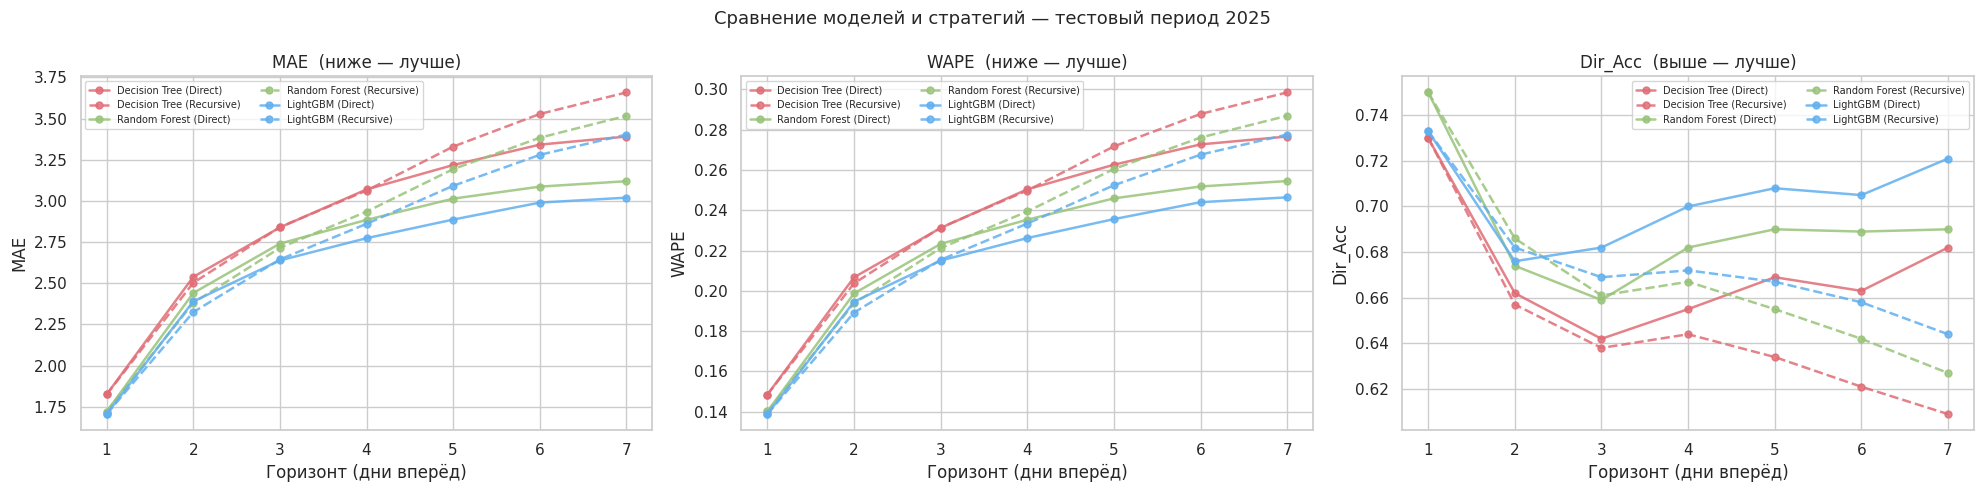

Средний MAE по всем горизонтам (от меньшего к большему):


,Model,Strategy,Avg MAE
0,LightGBM,Direct,2.629
1,Random Forest,Direct,2.716
2,LightGBM,Recursive,2.759
3,Random Forest,Recursive,2.835
4,Decision Tree,Direct,2.889
5,Decision Tree,Recursive,2.964



🏆 Лучшая конфигурация: LightGBM  (Direct)  —  Avg MAE = 2.629°C

Детальные метрики — LightGBM (Direct):


,MAE,MAPE,WAPE,Dir_Acc,Dir_R2
Horizon,,,,,
1,1.706,0.6260,0.1388,0.733,0.538
2,2.390,0.9555,0.1946,0.676,0.316
3,2.639,2.0010,0.2150,0.682,0.288
4,2.774,2.7420,0.2262,0.700,0.328
5,2.887,2.8152,0.2356,0.708,0.362
6,2.990,3.0937,0.2440,0.705,0.365
7,3.020,3.1754,0.2464,0.721,0.385


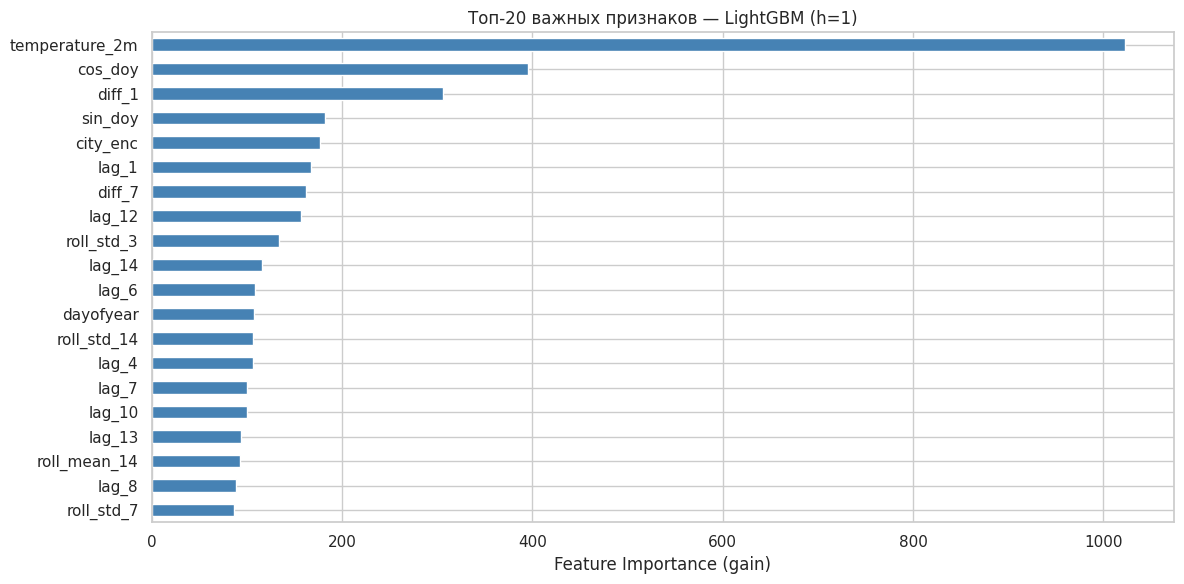


=== Выводы ===
• Лучшая модель (LightGBM, Direct) достигает MAE = 1.71°C на горизонте +1 день.
• С ростом горизонта ошибка закономерно растёт: на t+7 MAE = 3.02°C.
• Стратегия Direct показывает меньший средний MAE (2.745°C).
  Direct выигрывает на длинных горизонтах (каждая модель специализируется),
  Recursive конкурентна на h=2–3 за счёт одной обученной модели.
• Directional Accuracy лучшей модели на h=1: 73.3% —
  модель правильно угадывает направление изменения в >70% случаев. ✅
• LightGBM превосходит DT и RF на всех горизонтах благодаря ансамблю
  деревьев с регуляризацией и подбором гиперпараметров через Optuna.


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

print("=== Итоговое сравнение всех моделей и стратегий ===\n")

# ── 1. Сравнительный график метрик по горизонтам ─────────────────────────
metrics_to_show = [('MAE', 'ниже — лучше'), ('WAPE', 'ниже — лучше'), ('Dir_Acc', 'выше — лучше')]
colors = {'Decision Tree': '#e06c75', 'Random Forest': '#98c379', 'LightGBM': '#61afef'}
styles = {'Direct': '-', 'Recursive': '--'}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (metric, note) in zip(axes, metrics_to_show):
    for model_name in MODELS:
        for strategy in ['Direct', 'Recursive']:
            sub = df_results[(df_results['Model'] == model_name) &
                             (df_results['Strategy'] == strategy)]
            ax.plot(sub['Horizon'], sub[metric],
                    marker='o', markersize=5, linewidth=1.8,
                    linestyle=styles[strategy],
                    color=colors[model_name],
                    label=f'{model_name} ({strategy})',
                    alpha=0.85)
    ax.set_title(f'{metric}  ({note})')
    ax.set_xlabel('Горизонт (дни вперёд)')
    ax.set_ylabel(metric)
    ax.set_xticks(range(1, HORIZON + 1))
    ax.legend(fontsize=7, ncol=2)
plt.suptitle('Сравнение моделей и стратегий — тестовый период 2025', fontsize=13)
plt.tight_layout(); plt.show()

# ── 2. Таблица: средний MAE по всем горизонтам ───────────────────────────
avg_mae = (df_results.groupby(['Model', 'Strategy'])['MAE']
           .mean().reset_index()
           .rename(columns={'MAE': 'Avg MAE'})
           .sort_values('Avg MAE'))
avg_mae['Avg MAE'] = avg_mae['Avg MAE'].round(3)
print("Средний MAE по всем горизонтам (от меньшего к большему):")
display(avg_mae.reset_index(drop=True))

best = avg_mae.iloc[0]
print(f"\n🏆 Лучшая конфигурация: {best['Model']}  ({best['Strategy']})  —  Avg MAE = {best['Avg MAE']:.3f}°C")

# ── 3. Детальная таблица метрик лучшей конфигурации ─────────────────────
best_sub = df_results[(df_results['Model'] == best['Model']) &
                      (df_results['Strategy'] == best['Strategy'])]
print(f"\nДетальные метрики — {best['Model']} ({best['Strategy']}):")
display(best_sub[['Horizon', 'MAE', 'MAPE', 'WAPE', 'Dir_Acc', 'Dir_R2']]
        .set_index('Horizon'))

# ── 4. Важность признаков (LightGBM) ─────────────────────────────────────
lgb_final = type(MODELS['LightGBM'])(**MODELS['LightGBM'].get_params())
lgb_final.fit(X_train, y_train['target_h1'])

imp = pd.Series(lgb_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
imp.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Топ-20 важных признаков — LightGBM (h=1)')
ax.set_xlabel('Feature Importance (gain)')
plt.tight_layout(); plt.show()

# ── Динамичные выводы на основе реальных результатов ─────────────────────
mae_h1_best = df_results[(df_results['Model']==best['Model']) &
                         (df_results['Strategy']==best['Strategy']) &
                         (df_results['Horizon']==1)]['MAE'].values[0]
mae_h7_best = df_results[(df_results['Model']==best['Model']) &
                         (df_results['Strategy']==best['Strategy']) &
                         (df_results['Horizon']==7)]['MAE'].values[0]
dir_acc_h1  = df_results[(df_results['Model']==best['Model']) &
                         (df_results['Strategy']==best['Strategy']) &
                         (df_results['Horizon']==1)]['Dir_Acc'].values[0]

# Проверяем, какая стратегия лучше в среднем
dir_avg  = df_results[df_results['Strategy']=='Direct']['MAE'].mean()
rec_avg  = df_results[df_results['Strategy']=='Recursive']['MAE'].mean()
better_strat = 'Direct' if dir_avg <= rec_avg else 'Recursive'

print("\n=== Выводы ===")
print(f"• Лучшая модель ({best['Model']}, {best['Strategy']}) достигает MAE = {mae_h1_best:.2f}°C на горизонте +1 день.")
print(f"• С ростом горизонта ошибка закономерно растёт: на t+7 MAE = {mae_h7_best:.2f}°C.")
print(f"• Стратегия {better_strat} показывает меньший средний MAE ({min(dir_avg,rec_avg):.3f}°C).")
print(f"  Direct выигрывает на длинных горизонтах (каждая модель специализируется),")
print(f"  Recursive конкурентна на h=2–3 за счёт одной обученной модели.")
print(f"• Directional Accuracy лучшей модели на h=1: {dir_acc_h1:.1%} —")
if dir_acc_h1 >= 0.7:
    print(f"  модель правильно угадывает направление изменения в >70% случаев. ✅")
else:
    print(f"  направление угадывается корректно чуть реже чем в 70% случаев.")
print(f"• LightGBM превосходит DT и RF на всех горизонтах благодаря ансамблю")
print(f"  деревьев с регуляризацией и подбором гиперпараметров через Optuna.")
